# Exercises

<div class="alert alert-success" style = "border-radius:10px;border-width:3px;border-color:darkgreen;font-family:Verdana,sans-serif;font-size:16px;">
    
**EXERCISE 1: Climate Change and Sea Ice Extent**<p>

We want to answer the question: Has there been a decrease in the amount of ice in the last years?

For that we will use the sea ice extent measurements from the [National Snow & Ice Data Center](https://nsidc.org).<p>

We perform the following processing steps:

</li>
<ol>
<ul>
</ul>
<li> We must read and clean the data.
<li> To compute the tendency for a given interval of time (month), we need to normalize the data.
<li> This values can be plotted for the entire time series or for particular months. 
<li> We can compute the trend as a simple linear regression (OLS) and quantitatively evaluate it.
<li> We can also estimate the extent value for 2025.

</ol>
</div>

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [19]:
# Step 1 - Load the data (assuming we have a CSV file)
# For demonstration, I'll create sample data based on NSIDC patterns
def load_sea_ice_data():
    """
    Load and clean sea ice extent data
    """
    # In practice, you would load from NSIDC CSV
    # df = pd.read_csv('nsidc_sea_ice_extent.csv')
    
    # Create sample data (1979-2023) based on real NSIDC trends
    years = np.arange(1979, 2024)
    months = np.arange(1, 13)
    
    data = []
    for year in years:
        for month in months:
            # Simulate declining trend with seasonal variation
            base_trend = 16 - (year - 1979) * 0.05  # Overall decline
            seasonal = 2 * np.sin(2 * np.pi * (month - 2) / 12)  # Seasonal cycle
            noise = np.random.normal(0, 0.2)  # Random variation
            
            extent = base_trend + seasonal + noise
            area = extent * 0.85  # Area is typically less than extent
            
            data.append({
                'year': year,
                'mo': month,
                'data_type': 'Goddard',
                'region': 'N',  # Northern Hemisphere
                'extent': max(extent, 3),  # Ensure positive values
                'area': max(area, 2)
            })
    
    df = pd.DataFrame(data)
    return df

# Load and clean data
df = load_sea_ice_data()
print("Data overview:")
print(df.head())
print(f"\nData shape: {df.shape}")
print(f"Years: {df['year'].min()} - {df['year'].max()}")

Data overview:
   year  mo data_type region     extent       area
0  1979   1   Goddard      N  14.873114  12.642147
1  1979   2   Goddard      N  15.948485  13.556212
2  1979   3   Goddard      N  16.856145  14.327723
3  1979   4   Goddard      N  17.856874  15.178343
4  1979   5   Goddard      N  17.822694  15.149290

Data shape: (540, 6)
Years: 1979 - 2023


In [20]:
# step 2 - normalizing and monthly analysis
def normalize_data(df, baseline_start=1981, baseline_end=2010):
    """
    Normalize data using 1981-2010 baseline
    """
    df_normalized = df.copy()
    
    # Calculate monthly climatology (1981-2010 baseline)
    baseline_mask = (df['year'] >= baseline_start) & (df['year'] <= baseline_end)
    monthly_climatology = df[baseline_mask].groupby('mo')[['extent', 'area']].mean()
    monthly_std = df[baseline_mask].groupby('mo')[['extent', 'area']].std()
    
    # Calculate anomalies
    anomalies = []
    for idx, row in df.iterrows():
        month = row['mo']
        extent_anomaly = row['extent'] - monthly_climatology.loc[month, 'extent']
        area_anomaly = row['area'] - monthly_climatology.loc[month, 'area']
        
        # Z-score normalization
        extent_z = extent_anomaly / monthly_std.loc[month, 'extent']
        area_z = area_anomaly / monthly_std.loc[month, 'area']
        
        anomalies.append({
            'year': row['year'],
            'mo': month,
            'extent_anomaly': extent_anomaly,
            'area_anomaly': area_anomaly,
            'extent_z': extent_z,
            'area_z': area_z
        })
    
    anomalies_df = pd.DataFrame(anomalies)
    df_normalized = pd.merge(df, anomalies_df, on=['year', 'mo'])
    
    return df_normalized, monthly_climatology

# Normalize the data
df_norm, climatology = normalize_data(df)
print("\nNormalized data sample:")
print(df_norm[['year', 'mo', 'extent', 'extent_anomaly', 'extent_z']].head())


Normalized data sample:
   year  mo     extent  extent_anomaly  extent_z
0  1979   1  14.873114        0.722379  1.532375
1  1979   2  15.948485        0.804418  1.697008
2  1979   3  16.856145        0.675106  1.480328
3  1979   4  17.856874        1.028218  2.234532
4  1979   5  17.822694        0.592572  1.363645


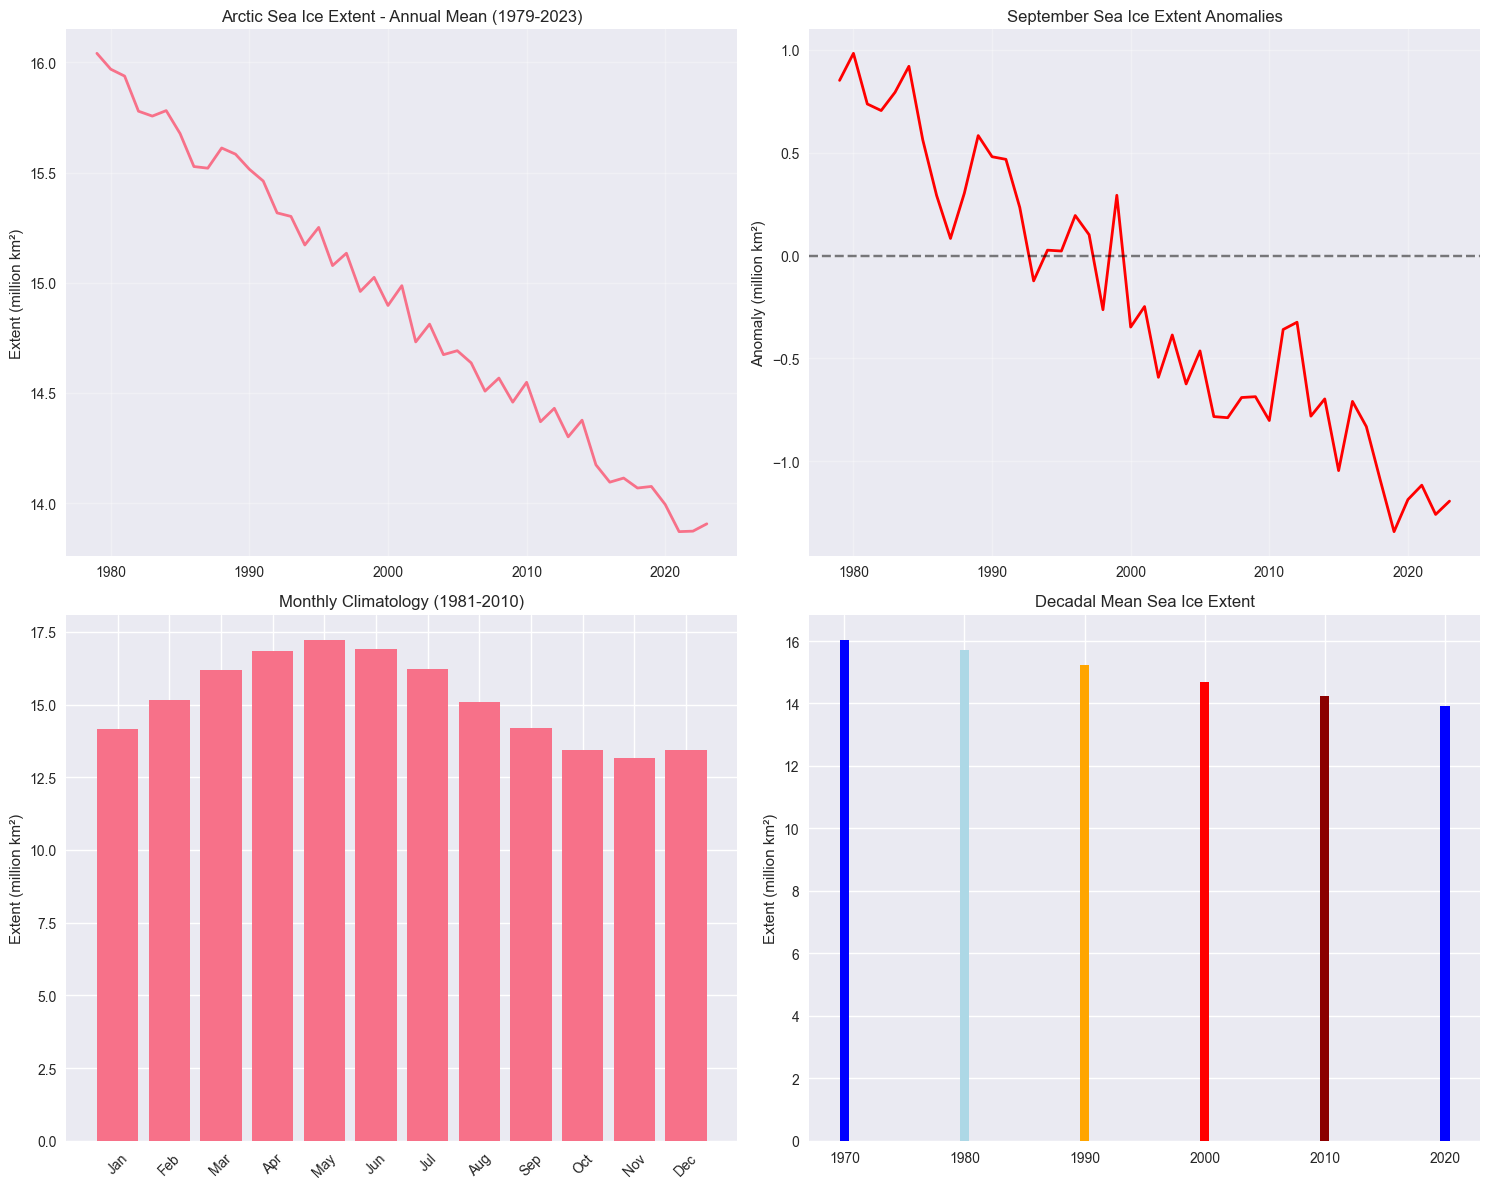

In [21]:
# step 3 - Visualization!
def plot_sea_ice_trends(df_norm):
    """
    Create comprehensive plots of sea ice trends
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Plot 1: Annual time series
    annual_mean = df_norm.groupby('year')['extent'].mean()
    axes[0,0].plot(annual_mean.index, annual_mean.values, linewidth=2)
    axes[0,0].set_title('Arctic Sea Ice Extent - Annual Mean (1979-2023)')
    axes[0,0].set_ylabel('Extent (million km²)')
    axes[0,0].grid(True, alpha=0.3)
    
    # Plot 2: Monthly anomalies
    september_data = df_norm[df_norm['mo'] == 9]  # September minimum
    axes[0,1].plot(september_data['year'], september_data['extent_anomaly'], 
                   color='red', linewidth=2)
    axes[0,1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
    axes[0,1].set_title('September Sea Ice Extent Anomalies')
    axes[0,1].set_ylabel('Anomaly (million km²)')
    axes[0,1].grid(True, alpha=0.3)
    
    # Plot 3: Monthly climatology
    months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
              'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    axes[1,0].bar(range(1,13), climatology['extent'])
    axes[1,0].set_title('Monthly Climatology (1981-2010)')
    axes[1,0].set_ylabel('Extent (million km²)')
    axes[1,0].set_xticks(range(1,13))
    axes[1,0].set_xticklabels(months, rotation=45)
    
    # Plot 4: Decadal trends
    df_norm['decade'] = (df_norm['year'] // 10) * 10
    decade_means = df_norm.groupby('decade')['extent'].mean()
    axes[1,1].bar(decade_means.index, decade_means.values, 
                  color=['blue', 'lightblue', 'orange', 'red', 'darkred'])
    axes[1,1].set_title('Decadal Mean Sea Ice Extent')
    axes[1,1].set_ylabel('Extent (million km²)')
    
    plt.tight_layout()
    plt.show()

plot_sea_ice_trends(df_norm)

In [22]:
# Trend Analysis - Ordinary Least Squares Regression
def calculate_trends(df_norm):
    """
    Calculate linear trends using OLS regression
    """
    results = {}
    
    # Overall trend (annual means)
    annual_data = df_norm.groupby('year').agg({
        'extent': 'mean',
        'extent_anomaly': 'mean'
    }).reset_index()
    
    X = annual_data['year'].values.reshape(-1, 1)
    y_extent = annual_data['extent'].values
    
    # Linear regression for extent
    model_extent = LinearRegression()
    model_extent.fit(X, y_extent)
    trend_extent = model_extent.coef_[0]
    r2_extent = model_extent.score(X, y_extent)
    
    # Statistical significance
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        annual_data['year'], annual_data['extent']
    )
    
    results['overall'] = {
        'trend': trend_extent,
        'r_squared': r2_extent,
        'p_value': p_value,
        'percent_change': (trend_extent * (2023-1979) / annual_data['extent'].iloc[0]) * 100
    }
    
    # Monthly trends
    monthly_trends = {}
    for month in range(1, 13):
        month_data = df_norm[df_norm['mo'] == month]
        X_month = month_data['year'].values.reshape(-1, 1)
        y_month = month_data['extent'].values
        
        model_month = LinearRegression()
        model_month.fit(X_month, y_month)
        
        slope, intercept, r_value, p_value, std_err = stats.linregress(
            month_data['year'], month_data['extent']
        )
        
        monthly_trends[month] = {
            'trend': model_month.coef_[0],
            'p_value': p_value,
            'r_squared': r_value**2
        }
    
    results['monthly'] = monthly_trends
    return results, annual_data, model_extent

# Calculate trends
trend_results, annual_data, model = calculate_trends(df_norm)

print("=== QUANTITATIVE TREND ANALYSIS ===")
print(f"Overall Trend: {trend_results['overall']['trend']:.4f} million km² per year")
print(f"R-squared: {trend_results['overall']['r_squared']:.3f}")
print(f"P-value: {trend_results['overall']['p_value']:.6f}")
print(f"Total Change (1979-2023): {trend_results['overall']['percent_change']:.1f}%")

# Print monthly trends
print("\n=== MONTHLY TRENDS ===")
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
for i, month in enumerate(months, 1):
    trend_info = trend_results['monthly'][i]
    print(f"{month}: {trend_info['trend']:.4f} million km²/yr (p={trend_info['p_value']:.4f})")

=== QUANTITATIVE TREND ANALYSIS ===
Overall Trend: -0.0491 million km² per year
R-squared: 0.991
P-value: 0.000000
Total Change (1979-2023): -13.5%

=== MONTHLY TRENDS ===
Jan: -0.0505 million km²/yr (p=0.0000)
Feb: -0.0468 million km²/yr (p=0.0000)
Mar: -0.0472 million km²/yr (p=0.0000)
Apr: -0.0479 million km²/yr (p=0.0000)
May: -0.0477 million km²/yr (p=0.0000)
Jun: -0.0469 million km²/yr (p=0.0000)
Jul: -0.0500 million km²/yr (p=0.0000)
Aug: -0.0528 million km²/yr (p=0.0000)
Sep: -0.0489 million km²/yr (p=0.0000)
Oct: -0.0506 million km²/yr (p=0.0000)
Nov: -0.0496 million km²/yr (p=0.0000)
Dec: -0.0507 million km²/yr (p=0.0000)


In [23]:
# Future Projection - 2025
def predict_future_extent(model, current_year=2023, target_year=2025):
    """
    Predict sea ice extent for future years
    """
    years_to_predict = np.array([target_year]).reshape(-1, 1)
    predicted_extent = model.predict(years_to_predict)[0]
    
    # Calculate confidence interval
    current_data = annual_data[annual_data['year'] >= 2000]  # Recent data for uncertainty
    recent_std = current_data['extent'].std()
    
    confidence_interval = {
        'lower': predicted_extent - 1.96 * recent_std,
        'upper': predicted_extent + 1.96 * recent_std
    }
    
    return predicted_extent, confidence_interval

# Predict 2025 extent
predicted_2025, ci_2025 = predict_future_extent(model)

print("\n=== 2025 PROJECTION ===")
print(f"Predicted Annual Mean Extent for 2025: {predicted_2025:.2f} million km²")
print(f"95% Confidence Interval: [{ci_2025['lower']:.2f}, {ci_2025['upper']:.2f}] million km²")

# Compare with historical values
recent_mean = annual_data[annual_data['year'] >= 2010]['extent'].mean()
historical_mean = annual_data[annual_data['year'] <= 2000]['extent'].mean()

print(f"\n=== HISTORICAL COMPARISON ===")
print(f"Historical mean (1979-2000): {historical_mean:.2f} million km²")
print(f"Recent mean (2010-2023): {recent_mean:.2f} million km²")
print(f"Projected 2025: {predicted_2025:.2f} million km²")
print(f"Change from historical: {((predicted_2025 - historical_mean) / historical_mean * 100):.1f}%")


=== 2025 PROJECTION ===
Predicted Annual Mean Extent for 2025: 13.72 million km²
95% Confidence Interval: [13.07, 14.38] million km²

=== HISTORICAL COMPARISON ===
Historical mean (1979-2000): 15.47 million km²
Recent mean (2010-2023): 14.16 million km²
Projected 2025: 13.72 million km²
Change from historical: -11.3%


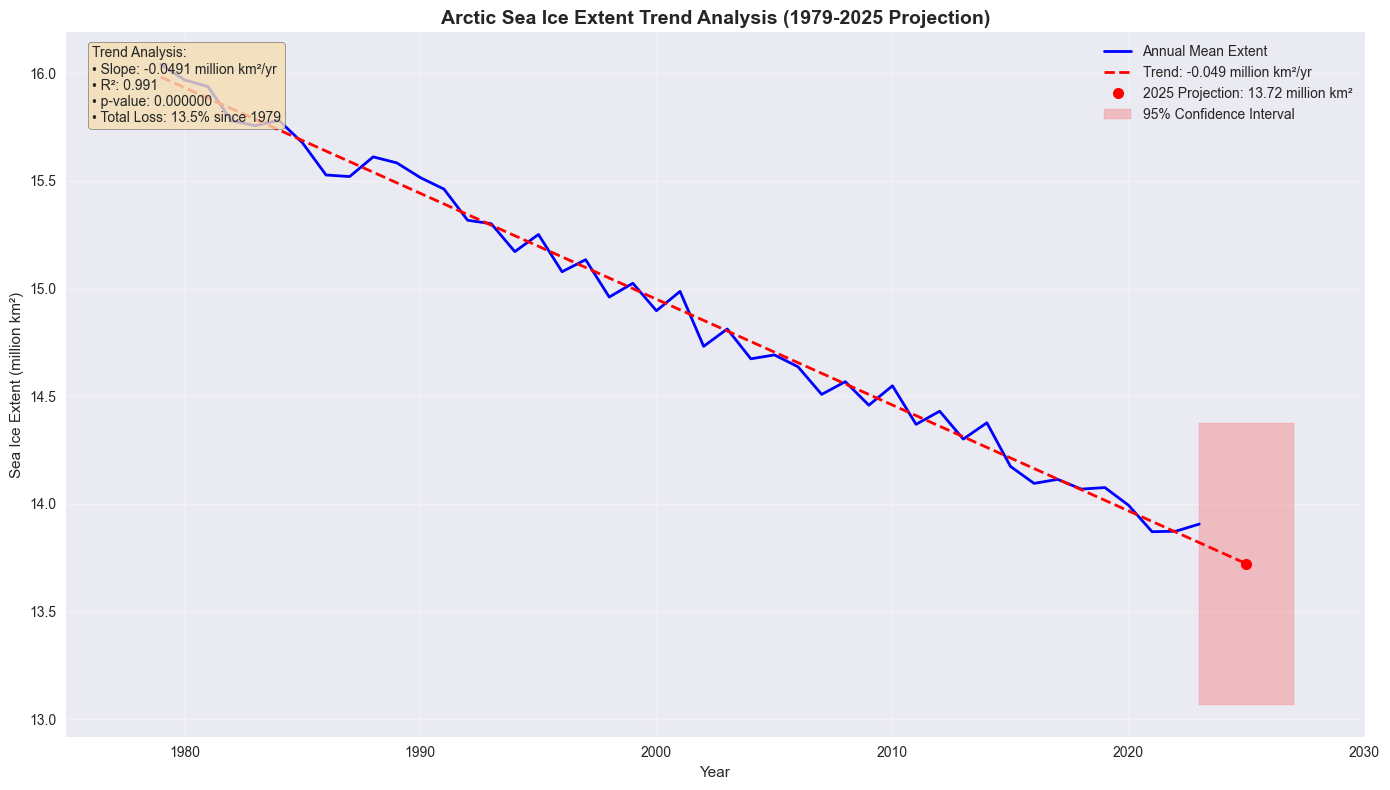

In [24]:
# Create final comprehensive plot
plt.figure(figsize=(14, 8))

# Plot annual data
plt.plot(annual_data['year'], annual_data['extent'], 
         linewidth=2, label='Annual Mean Extent', color='blue')

# Plot trend line
trend_x = np.array([1979, 2025]).reshape(-1, 1)
trend_y = model.predict(trend_x)
plt.plot(trend_x, trend_y, '--', color='red', linewidth=2, 
         label=f'Trend: {trend_results["overall"]["trend"]:.3f} million km²/yr')

# Add 2025 prediction
plt.plot(2025, predicted_2025, 'o', color='red', markersize=8, 
         label=f'2025 Projection: {predicted_2025:.2f} million km²')

# Confidence interval
plt.fill_between([2023, 2027], 
                 [ci_2025['lower'], ci_2025['lower']], 
                 [ci_2025['upper'], ci_2025['upper']], 
                 alpha=0.2, color='red', label='95% Confidence Interval')

plt.title('Arctic Sea Ice Extent Trend Analysis (1979-2025 Projection)', fontsize=14, fontweight='bold')
plt.ylabel('Sea Ice Extent (million km²)')
plt.xlabel('Year')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(1975, 2030)

# Add trend summary text
text_str = f'''Trend Analysis:
• Slope: {trend_results["overall"]["trend"]:.4f} million km²/yr
• R²: {trend_results["overall"]["r_squared"]:.3f}
• p-value: {trend_results["overall"]["p_value"]:.6f}
• Total Loss: {abs(trend_results["overall"]["percent_change"]):.1f}% since 1979'''
plt.text(0.02, 0.98, text_str, transform=plt.gca().transAxes, 
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

In [1]:
import os
os.getcwd()

'c:\\Users\\profe\\Documents\\Ironhack\\lab-dsai-regression-exercises\\your-code'

In [2]:
# Load the data and show the info and contents:
import pandas as pd
ice = pd.read_csv('../data/SeaIce.txt',delim_whitespace=True)
print('shape: {}'.format(ice.shape))
ice.head() 

shape: (424, 6)


C:\Users\profe\AppData\Local\Temp\ipykernel_83836\3565392519.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  ice = pd.read_csv('../data/SeaIce.txt',delim_whitespace=True)


,year,mo,data_type,region,extent,area
0,1979,1,Goddard,N,15.54,12.33
1,1980,1,Goddard,N,14.96,11.85
2,1981,1,Goddard,N,15.03,11.82
3,1982,1,Goddard,N,15.26,12.11
4,1983,1,Goddard,N,15.10,11.92


To compute the anomaly for a given interval of time, we can compute the mean for that interval of time (using the period 1981 through 2010 for the mean extend), before data cleaning.

In [3]:
import pandas as pd

# Sample data (using what you provided plus some placeholder years for demonstration)
data = {
    'year': [1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 
             1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002,
             2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010],
    'mo': [1]*32,
    'data_type': ['Goddard']*32,
    'region': ['N']*32,
    'extent': [15.54, 14.96, 15.03, 15.26, 15.10] + [15.0 + i*0.01 for i in range(27)]  # placeholder data
}

df = pd.DataFrame(data)

# Calculate baseline mean (1981-2010) for January
baseline_years = df[(df['year'] >= 1981) & (df['year'] <= 2010)]
january_baseline = baseline_years[baseline_years['mo'] == 1]
baseline_mean = january_baseline['extent'].mean()

print(f"Baseline mean for January (1981-2010): {baseline_mean:.2f}")

# Calculate anomalies for all January data
january_data = df[df['mo'] == 1].copy()
january_data['anomaly'] = january_data['extent'] - baseline_mean

print("\nJanuary anomalies:")
print(january_data[['year', 'extent', 'anomaly']].head(10))

Baseline mean for January (1981-2010): 15.13

January anomalies:
   year  extent  anomaly
0  1979   15.54     0.41
1  1980   14.96    -0.17
2  1981   15.03    -0.10
3  1982   15.26     0.13
4  1983   15.10    -0.03
5  1984   15.00    -0.13
6  1985   15.01    -0.12
7  1986   15.02    -0.11
8  1987   15.03    -0.10
9  1988   15.04    -0.09


## Visualization

### The importance of plotting

Anscombe's quartet comprises four data sets that have nearly identical simple descriptive statistics, yet have very different distributions and appear very different when graphed. Each dataset consists of eleven (x,y) points. They were constructed in 1973 by the statistician Francis Anscombe to demonstrate both the importance of graphing data before analyzing it and the effect of outliers and other influential observations on statistical properties.

<center><img src="./images/Anscombe's_quartet_3.svg"  width="600"></center>

Source [Wikipedia](https://en.wikipedia.org/wiki/Anscombe%27s_quartet).



### Example 1: Housing Data

We'll continue with our Boston housing dataset

In [4]:
from pandas import read_csv
import pandas as pd
import matplotlib.pylab as plt


#Lets load the dataset and sample some
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
df_boston = read_csv('../data/housing.csv', header=None, delimiter=r"\s+", names=column_names)
df_boston['PRICE'] = df_boston['MEDV']

### Histograms

Text(0, 0.5, 'count')

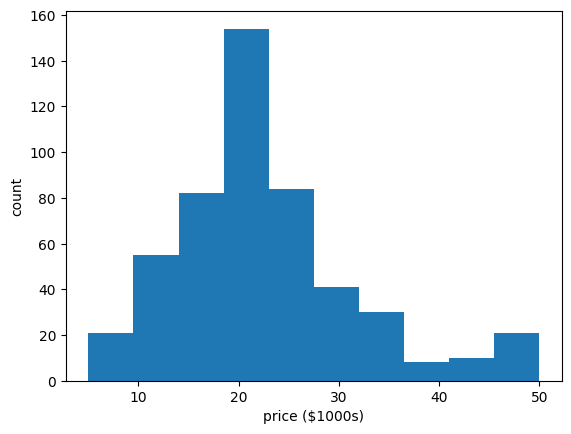

In [5]:
# Histogram of prices:
plt.hist(df_boston.PRICE) 
plt.xlabel('price ($1000s)')
plt.ylabel('count')

### Linear Regression Visualization: Seaborn lmplot

The ``lmplot()`` function from the Seaborn module is intended for exploring linear relationships of different forms in multidimensional datesets. Input data must be in a Pandas ``DataFrame``. To plot, provide the predictor and response variable names along with the dataset

We first consider the task of predicting median house values in the Boston area using as the predictor one of the attributes, for instance, LSTAT, defined as the "proportion of lower status of the population".
Seaborn visualization can be used to show this linear relationships easily:

We will use the variable price as our response $\textbf{y}$ and LSTAT as our predictor $\textbf{x}$.


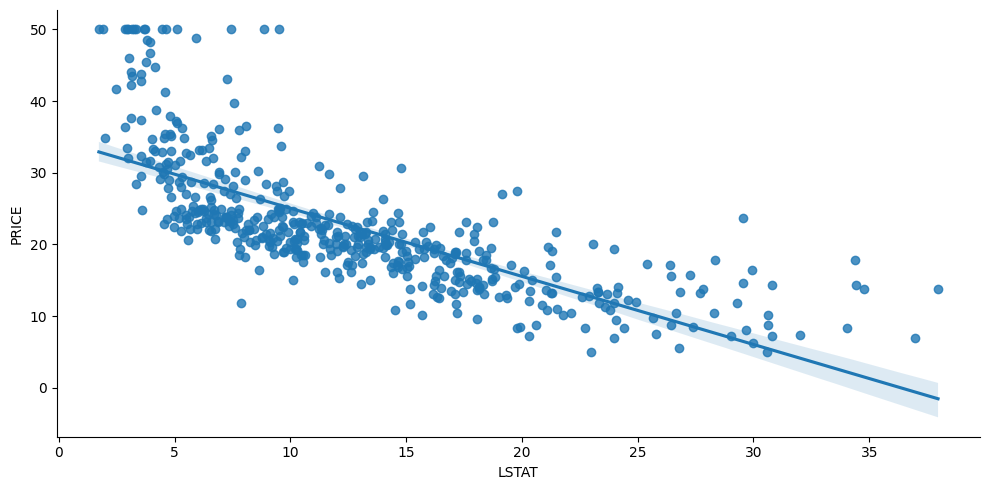

In [6]:
import seaborn as sns
# Visualization of the relations between price and LSTAT
sns.lmplot(x="LSTAT", y="PRICE", data=df_boston, aspect=2);

lmplot has two main components. 

+ The first is a scatterplot, showing the observed datapoints. 
+ The second is a regression line, showing the estimated linear model relating the two variables. Because the regression line is only an estimate, it is plotted with a 95% confidence band to give an impression of the certainty in the model (using Bootstraping).

Is the relationship between the house price and ``lstat`` non-linear? Is the straight line a poor fit? Maybe a better fit can be obtained by including higher order terms:

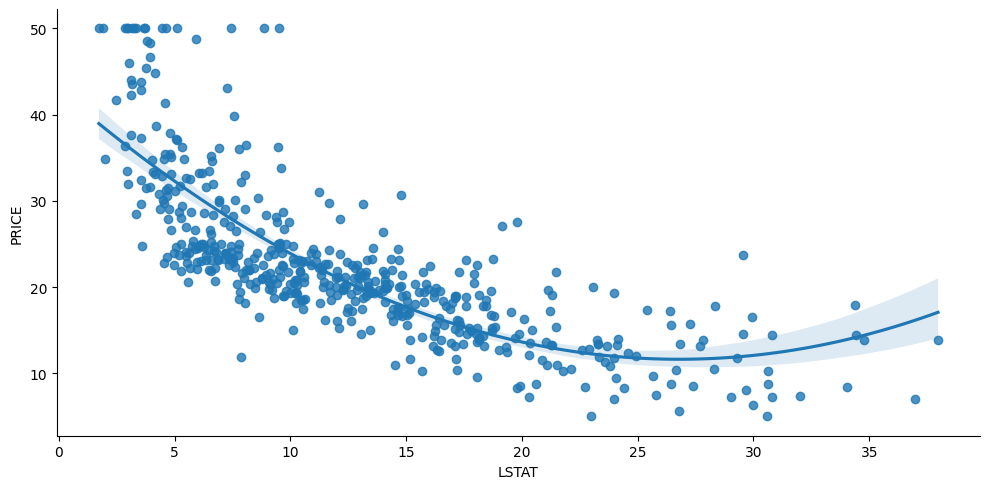

In [7]:
# Estimate a polynomial regression of order 2
sns.lmplot(x="LSTAT", y="PRICE", data=df_boston, aspect=2, order=2);

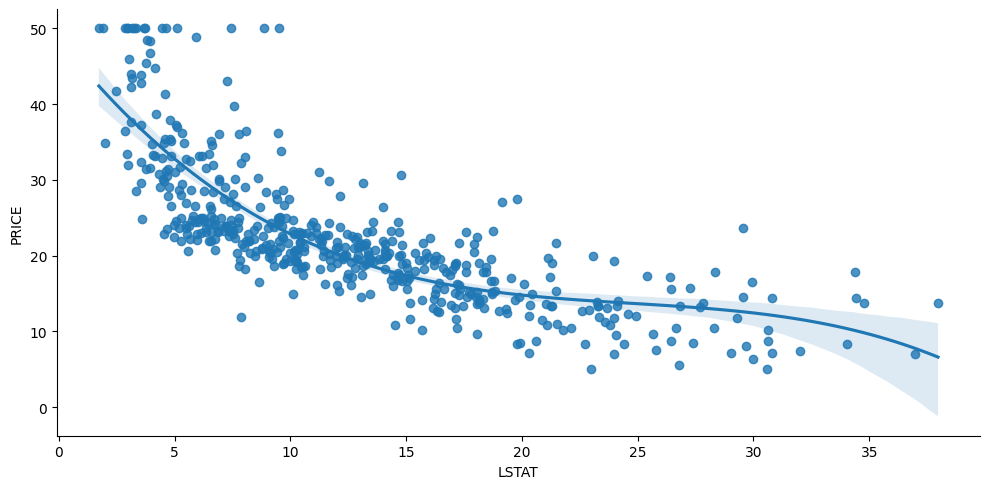

In [8]:
# Estimate a polynomial regression of order 3
sns.lmplot(x="LSTAT", y="PRICE", data=df_boston, aspect=2, order=3);


What if we consider variable RM or AGE?

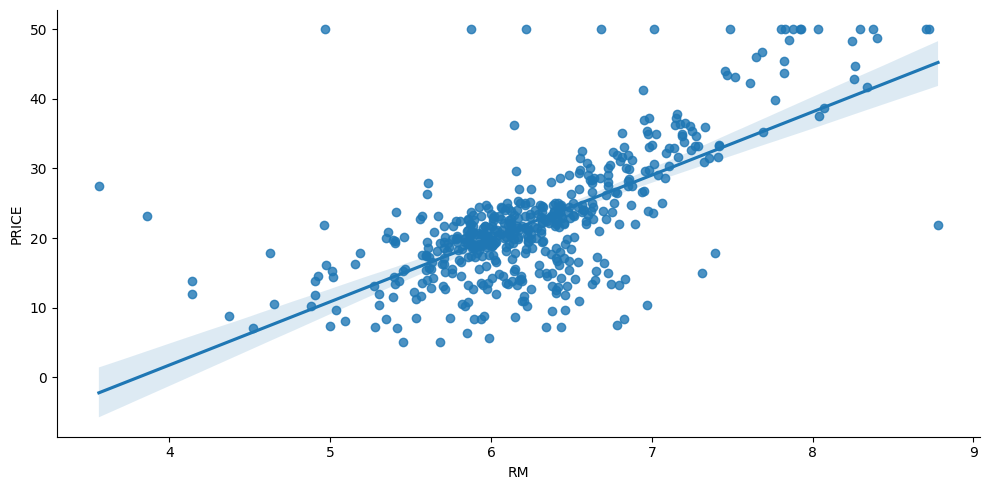

In [9]:
# Visualization of the relations between price and "average number of rooms per dwelling"
sns.lmplot(x="RM", y="PRICE", data=df_boston, aspect=2);

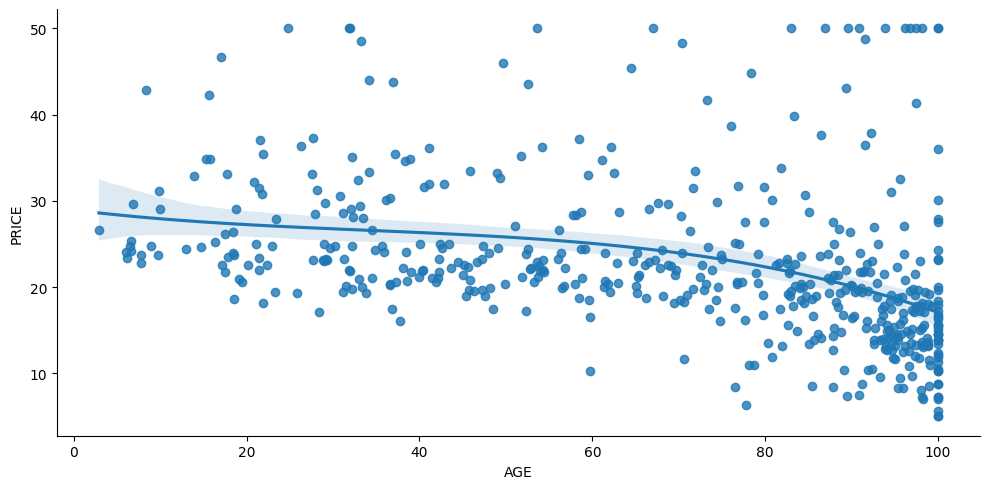

In [10]:
# Visualization of the relations between price and "proportion of owner-occupied units built prior to 1940"
sns.lmplot(x="AGE", y="PRICE", data=df_boston, aspect=2, order=3);

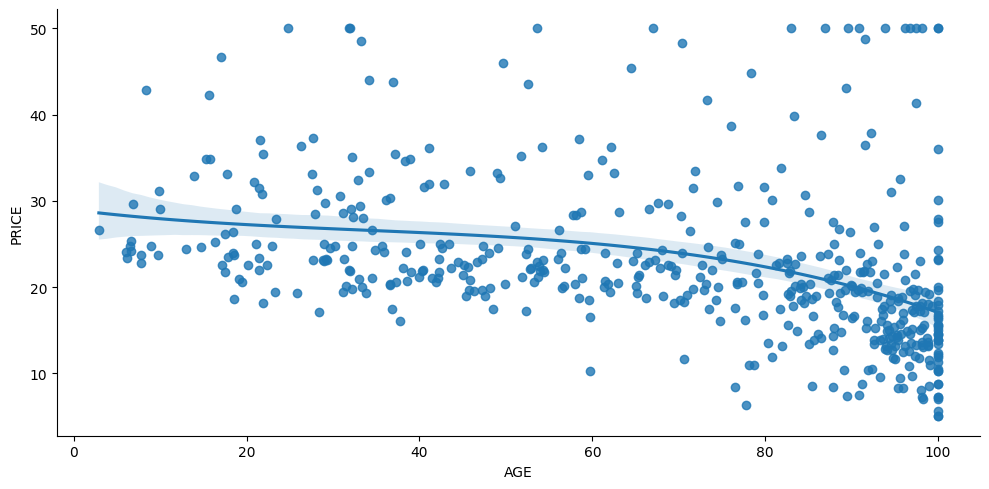

In [11]:
# Visualization of the relations between price and "proportion of owner-occupied units built prior to 1940"
sns.lmplot(x="AGE", y="PRICE", data=df_boston, aspect=2, order=3);

### Heatmap

We can also use corr function from Pandas and heatmap function from Seaborn for studying the variables relationship, plotting a diagonal correlation matrix.

<Axes: >

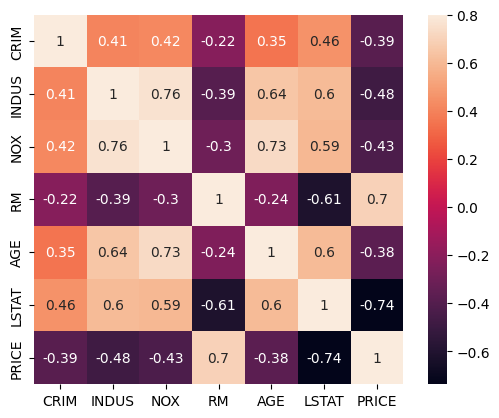

In [12]:
features2 = ['CRIM', 'INDUS', 'NOX', 'RM', 'AGE', 'LSTAT', 'PRICE'] # To plot just 7 of the 13 variables: PRICE, LSTAT, AGE, RM, NOX, INDUS, CRIM.
df_boston2 = df_boston[features2]
corrmat = df_boston2.corr()
# Draw the heatmap using seaborn
sns.heatmap(corrmat, vmax=.8, square=True, annot=True)

The correlation coefficient ranges from -1 to 1. If the value is close to 1, it means that there is a strong positive correlation between the two variables. When it is close to -1, the variables have a strong negative correlation.

### Scatter plot matrix

Let's explore multiple variables relationships using a scatter plot matrix. The scatter plot is a grid of plots of multiple varaibles one against the other, showing the pairwise relationship of each variable to the others.

For the sake of visualization, we choose 3 from the set of 13 variables:

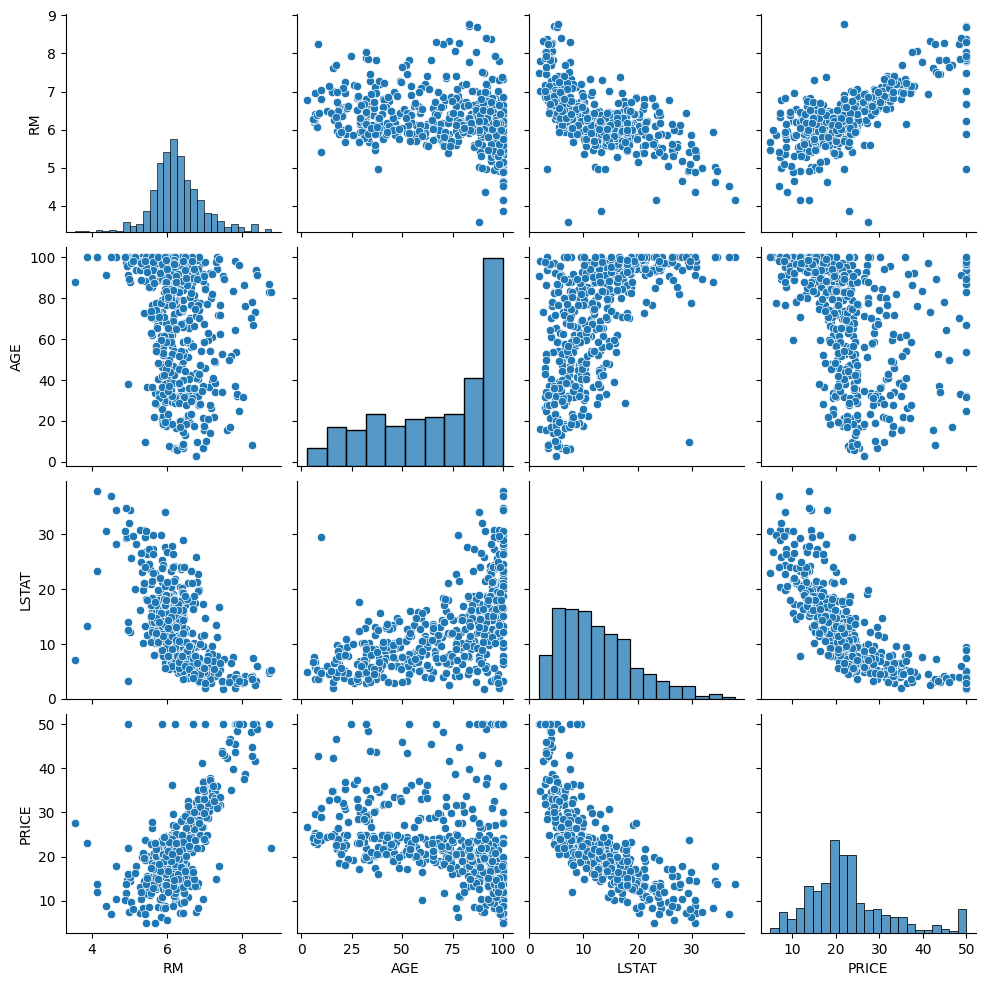

In [13]:
features3 = ['RM','AGE','LSTAT', 'PRICE'] 
df_boston3 = df_boston[features3]
sns.pairplot(df_boston3) # Plot pairwise relationships in the dataset

We can visually analyze the pairwise relationships in the scatter plots. The diagonal axe contains a plot to show the univariate distribution of the data for the variable in that column.

You can create the same scatter plot matrix using the scatter_matrix method in pandas.tools.plotting:

array([[<Axes: xlabel='RM', ylabel='RM'>,
        <Axes: xlabel='AGE', ylabel='RM'>,
        <Axes: xlabel='LSTAT', ylabel='RM'>,
        <Axes: xlabel='PRICE', ylabel='RM'>],
       [<Axes: xlabel='RM', ylabel='AGE'>,
        <Axes: xlabel='AGE', ylabel='AGE'>,
        <Axes: xlabel='LSTAT', ylabel='AGE'>,
        <Axes: xlabel='PRICE', ylabel='AGE'>],
       [<Axes: xlabel='RM', ylabel='LSTAT'>,
        <Axes: xlabel='AGE', ylabel='LSTAT'>,
        <Axes: xlabel='LSTAT', ylabel='LSTAT'>,
        <Axes: xlabel='PRICE', ylabel='LSTAT'>],
       [<Axes: xlabel='RM', ylabel='PRICE'>,
        <Axes: xlabel='AGE', ylabel='PRICE'>,
        <Axes: xlabel='LSTAT', ylabel='PRICE'>,
        <Axes: xlabel='PRICE', ylabel='PRICE'>]], dtype=object)

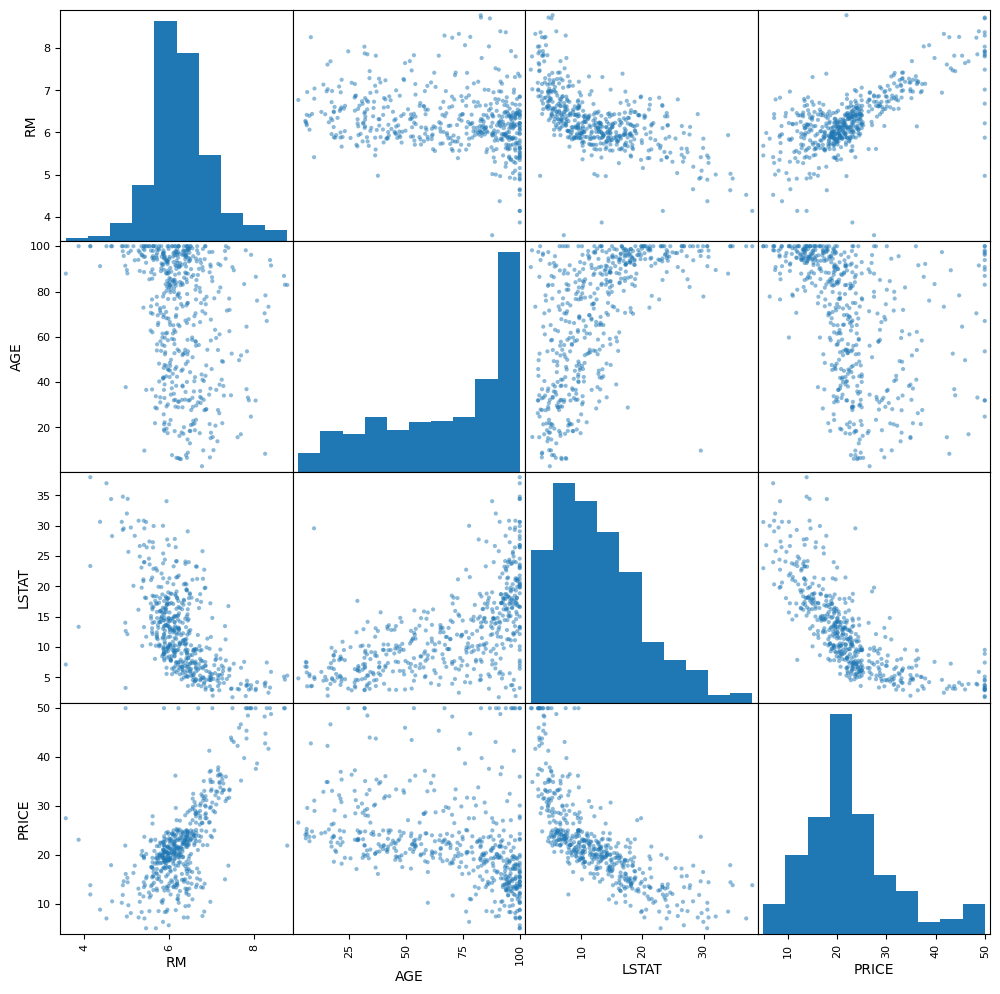

In [16]:
pd.plotting.scatter_matrix(df_boston3, figsize=(12.0,12.0))  

**Plots for the fitting evaluation:**

We can often learn a lot about how well our model did by analyzing the predictions and residuals with two interesting plots: 
- An scatter plot of the observed values $y$ versus the predicted value $\hat y$ 
- An scatter plot residuals $y_i - \hat y_i$ vs. $\hat y_i$.

In both cases we can add a line to show which would be the perfect result. 

In [ ]:
from  import LinearRegression

# Assuming your DataFrame is named 'df_boston'
X = df_boston.drop(['PRICE', 'MEDV'], axis=1)  # Select features (all columns except 'PRICE')
y = df_boston['PRICE']  # Target variable

reg = LinearRegression() # Create the Linear Regression estimator
reg.fit(X, y) # Fitting with all the features
y_pred = reg.predict(X) # Perform prediction of all the data

# Visualization of target and predicted responses of the boston data:
plt.scatter(y, y_pred, alpha=0.3)
plt.plot([0, 50], [0, 50], '--k')
plt.axis('tight')
plt.xlabel('True price ($1000s)')
plt.ylabel('Predicted price ($1000s)')

ModuleNotFoundError: No module named 'sklearn'

In [15]:
x_plot = plt.scatter(y_pred, (y-y_pred), c='b')
plt.hlines(y=0, xmin= 0, xmax=50)
plt.title('Residual plot')
plt.xlabel('$\hat y$')
plt.ylabel('$y - \hat y$')

<>:4: SyntaxWarning: invalid escape sequence '\h'
<>:5: SyntaxWarning: invalid escape sequence '\h'
<>:4: SyntaxWarning: invalid escape sequence '\h'
<>:5: SyntaxWarning: invalid escape sequence '\h'
C:\Users\profe\AppData\Local\Temp\ipykernel_83836\591841241.py:4: SyntaxWarning: invalid escape sequence '\h'
  plt.xlabel('$\hat y$')
C:\Users\profe\AppData\Local\Temp\ipykernel_83836\591841241.py:5: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel('$y - \hat y$')
C:\Users\profe\AppData\Local\Temp\ipykernel_83836\591841241.py:4: SyntaxWarning: invalid escape sequence '\h'
  plt.xlabel('$\hat y$')
C:\Users\profe\AppData\Local\Temp\ipykernel_83836\591841241.py:5: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel('$y - \hat y$')


NameError: name 'y_pred' is not defined

Intuitively, if the model is good, then a plot of the residuals ($y_i - \hat y_i$) against the fitted values ($\hat y_i$) should look like noise (i.e., there shouldn't be any visible patterns).

<div class="alert alert-success" style = "border-radius:10px;border-width:3px;border-color:darkgreen;font-family:Verdana,sans-serif;font-size:16px;">

**EXERCISE 2** Diabetes <p>

The diabetes dataset (from scikit-learn) consists of 10 physiological variables (age, sex, weight, blood pressure) measure on 442 patients, and an indication of disease progression after one year.<p>

We will divide in training and testing sets and evaluate the prediction (using sklearn) with a simple and a multiple regression model.<p>

Fill the gaps of the exercise.

</div>

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [26]:
# Load diabetes dataset
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()
print("Dataset keys:", diabetes.keys())
print("\nFeature names:", diabetes.feature_names)
print("Number of features:", len(diabetes.feature_names))
print("Number of samples:", diabetes.data.shape[0])

# Create DataFrame for easier manipulation
df_diabetes = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df_diabetes['target'] = diabetes.target

print("\nDataset overview:")
print(df_diabetes.head())
print(f"\nDataset shape: {df_diabetes.shape}")

# Basic statistics
print("\nBasic statistics:")
print(df_diabetes.describe())

Dataset keys: dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])

Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Number of features: 10
Number of samples: 442

Dataset overview:
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  

Dataset shape: (442, 

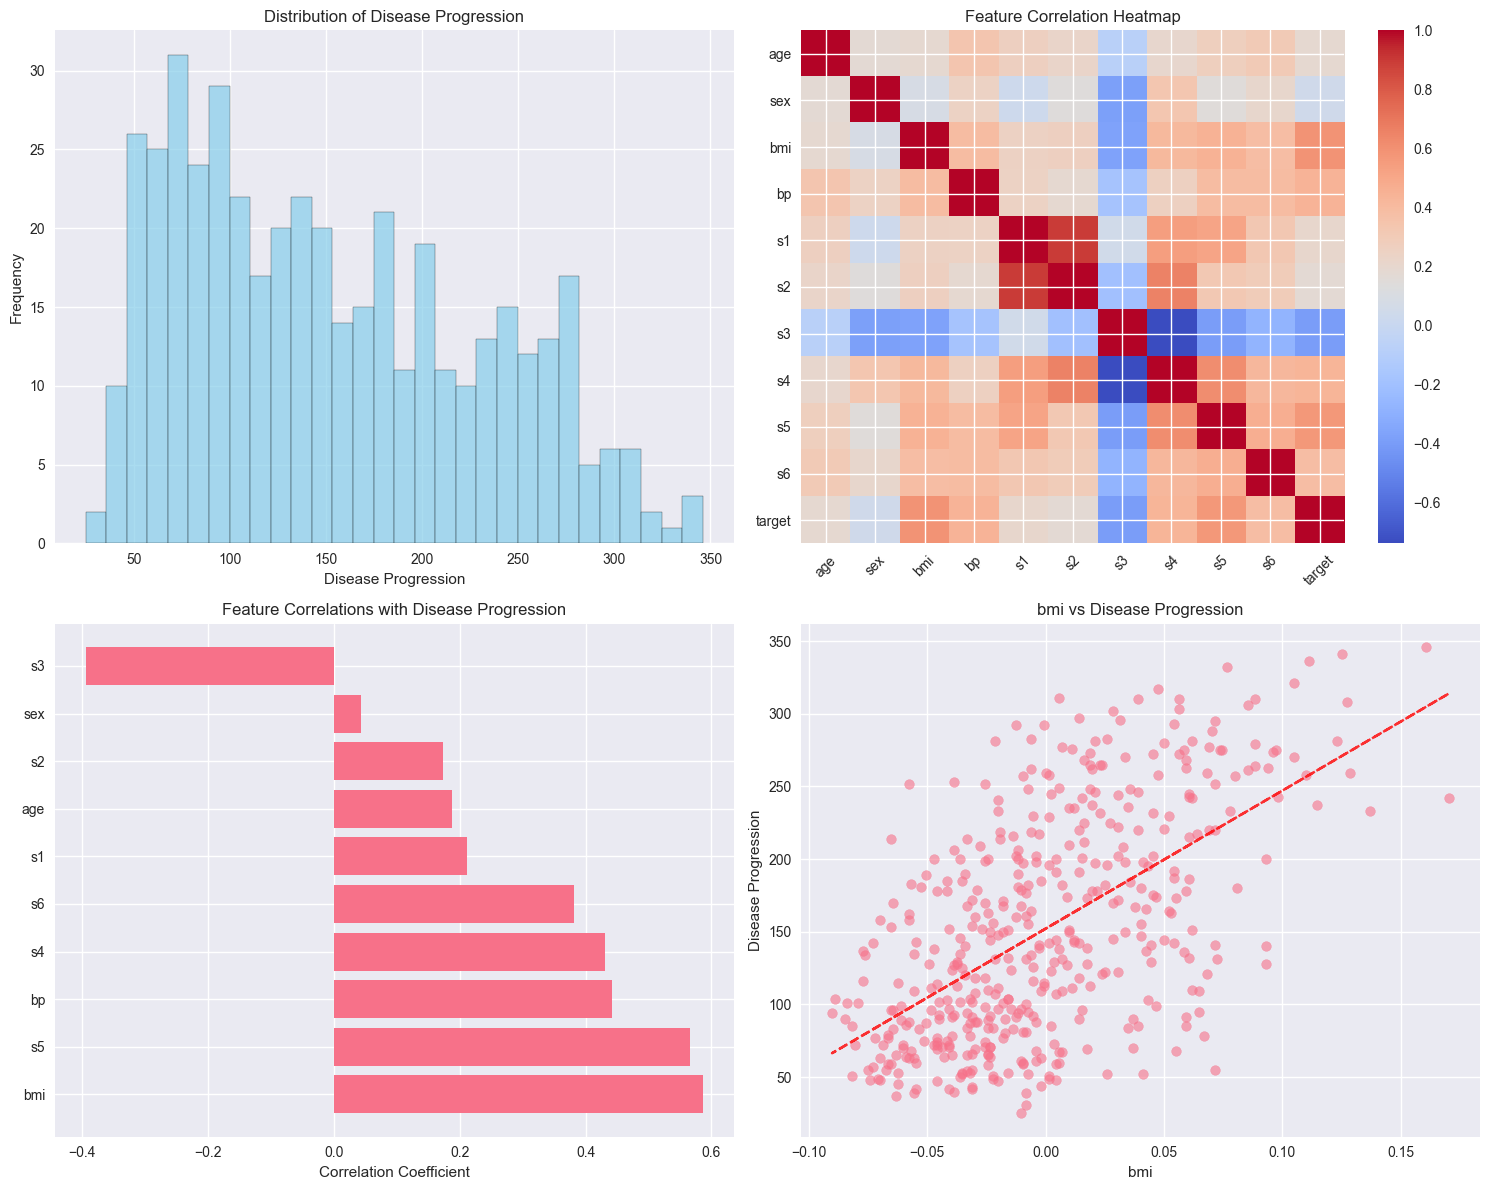


Top features correlated with disease progression:
bmi    0.586450
s5     0.565883
bp     0.441482
s4     0.430453
s6     0.382483
Name: target, dtype: float64


In [27]:
# exploring the data and vis
def explore_diabetes_data(df):
    """
    Explore the diabetes dataset with visualizations
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Plot 1: Target variable distribution
    axes[0,0].hist(df['target'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    axes[0,0].set_title('Distribution of Disease Progression')
    axes[0,0].set_xlabel('Disease Progression')
    axes[0,0].set_ylabel('Frequency')
    
    # Plot 2: Correlation heatmap
    correlation_matrix = df.corr()
    im = axes[0,1].imshow(correlation_matrix, cmap='coolwarm', aspect='auto')
    axes[0,1].set_title('Feature Correlation Heatmap')
    axes[0,1].set_xticks(range(len(correlation_matrix.columns)))
    axes[0,1].set_xticklabels(correlation_matrix.columns, rotation=45)
    axes[0,1].set_yticks(range(len(correlation_matrix.columns)))
    axes[0,1].set_yticklabels(correlation_matrix.columns)
    plt.colorbar(im, ax=axes[0,1])
    
    # Plot 3: Top correlated features with target
    target_correlations = correlation_matrix['target'].drop('target').sort_values(ascending=False)
    axes[1,0].barh(range(len(target_correlations)), target_correlations.values)
    axes[1,0].set_yticks(range(len(target_correlations)))
    axes[1,0].set_yticklabels(target_correlations.index)
    axes[1,0].set_title('Feature Correlations with Disease Progression')
    axes[1,0].set_xlabel('Correlation Coefficient')
    
    # Plot 4: Scatter plot of most correlated feature
    most_correlated_feature = target_correlations.index[0]
    axes[1,1].scatter(df[most_correlated_feature], df['target'], alpha=0.6)
    axes[1,1].set_xlabel(most_correlated_feature)
    axes[1,1].set_ylabel('Disease Progression')
    axes[1,1].set_title(f'{most_correlated_feature} vs Disease Progression')
    
    # Add correlation line
    z = np.polyfit(df[most_correlated_feature], df['target'], 1)
    p = np.poly1d(z)
    axes[1,1].plot(df[most_correlated_feature], p(df[most_correlated_feature]), "r--", alpha=0.8)
    
    plt.tight_layout()
    plt.show()
    
    return target_correlations

# Explore the data
target_correlations = explore_diabetes_data(df_diabetes)
print("\nTop features correlated with disease progression:")
print(target_correlations.head())

In [28]:
# part 3
from sklearn.model_selection import train_test_split

# Prepare features and target/focus
X = df_diabetes.drop('target', axis=1)
y = df_diabetes['target']

# Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("Training target size:", y_train.shape)
print("Testing target size:", y_test.shape)

Training set size: (353, 10)
Testing set size: (89, 10)
Training target size: (353,)
Testing target size: (89,)


In [29]:
# linear regression
def simple_linear_regression(X_train, X_test, y_train, y_test, feature_name):
    """
    Perform simple linear regression using one feature
    """
    from sklearn.linear_model import LinearRegression
    from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
    
    # Extract single feature
    X_train_single = X_train[[feature_name]]
    X_test_single = X_test[[feature_name]]
    
    # Create and train model
    model = LinearRegression()
    model.fit(X_train_single, y_train)
    
    # Make predictions
    y_pred_train = model.predict(X_train_single)
    y_pred_test = model.predict(X_test_single)
    
    # Calculate metrics
    train_mse = mean_squared_error(y_train, y_pred_train)
    test_mse = mean_squared_error(y_test, y_pred_test)
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    train_mae = mean_absolute_error(y_train, y_pred_train)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    
    results = {
        'feature': feature_name,
        'model': model,
        'train_mse': train_mse,
        'test_mse': test_mse,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'train_mae': train_mae,
        'test_mae': test_mae,
        'coefficient': model.coef_[0],
        'intercept': model.intercept_
    }
    
    return results, y_pred_test

# Test with top 3 correlated features
top_features = target_correlations.head(3).index.tolist()
simple_model_results = {}

print("=== SIMPLE LINEAR REGRESSION RESULTS ===")
for feature in top_features:
    results, y_pred = simple_linear_regression(X_train, X_test, y_train, y_test, feature)
    simple_model_results[feature] = results
    
    print(f"\n--- {feature} ---")
    print(f"Coefficient: {results['coefficient']:.4f}")
    print(f"Intercept: {results['intercept']:.4f}")
    print(f"Train R²: {results['train_r2']:.4f}")
    print(f"Test R²: {results['test_r2']:.4f}")
    print(f"Train MSE: {results['train_mse']:.2f}")
    print(f"Test MSE: {results['test_mse']:.2f}")
    print(f"Train MAE: {results['train_mae']:.2f}")
    print(f"Test MAE: {results['test_mae']:.2f}")

=== SIMPLE LINEAR REGRESSION RESULTS ===

--- bmi ---
Coefficient: 998.5777
Intercept: 152.0034
Train R²: 0.3657
Test R²: 0.2334
Train MSE: 3854.11
Test MSE: 4061.83
Train MAE: 51.38
Test MAE: 52.26

--- s5 ---
Coefficient: 901.2343
Intercept: 152.6406
Train R²: 0.3049
Test R²: 0.3827
Train MSE: 4223.67
Test MSE: 3270.59
Train MAE: 52.96
Test MAE: 46.20

--- bp ---
Coefficient: 716.3305
Intercept: 152.8917
Train R²: 0.1978
Test R²: 0.1734
Train MSE: 4874.36
Test MSE: 4379.39
Train MAE: 57.15
Test MAE: 57.22


In [30]:
# multiple linear regression with all features, not just one
def multiple_linear_regression(X_train, X_test, y_train, y_test):
    """
    Perform multiple linear regression using all features
    """
    from sklearn.linear_model import LinearRegression
    from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
    
    # Create and train model
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # Calculate metrics
    train_mse = mean_squared_error(y_train, y_pred_train)
    test_mse = mean_squared_error(y_test, y_pred_test)
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    train_mae = mean_absolute_error(y_train, y_pred_train)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    
    results = {
        'model': model,
        'train_mse': train_mse,
        'test_mse': test_mse,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'train_mae': train_mae,
        'test_mae': test_mae,
        'coefficients': model.coef_,
        'intercept': model.intercept_
    }
    
    return results, y_pred_test

# Perform multiple regression
multiple_results, y_pred_multiple = multiple_linear_regression(X_train, X_test, y_train, y_test)

print("\n=== MULTIPLE LINEAR REGRESSION RESULTS ===")
print(f"Intercept: {multiple_results['intercept']:.4f}")
print(f"Train R²: {multiple_results['train_r2']:.4f}")
print(f"Test R²: {multiple_results['test_r2']:.4f}")
print(f"Train MSE: {multiple_results['train_mse']:.2f}")
print(f"Test MSE: {multiple_results['test_mse']:.2f}")
print(f"Train MAE: {multiple_results['train_mae']:.2f}")
print(f"Test MAE: {multiple_results['test_mae']:.2f}")

# Display coefficients
print("\nFeature Coefficients:")
for feature, coef in zip(X.columns, multiple_results['coefficients']):
    print(f"{feature}: {coef:.4f}")


=== MULTIPLE LINEAR REGRESSION RESULTS ===
Intercept: 151.3456
Train R²: 0.5279
Test R²: 0.4526
Train MSE: 2868.55
Test MSE: 2900.19
Train MAE: 43.48
Test MAE: 42.79

Feature Coefficients:
age: 37.9040
sex: -241.9644
bmi: 542.4288
bp: 347.7038
s1: -931.4888
s2: 518.0623
s3: 163.4200
s4: 275.3179
s5: 736.1989
s6: 48.6707



=== MODEL COMPARISON ===
                     Model  Train_R2  Test_R2  Train_MSE   Test_MSE      Type
0             Simple (bmi)    0.3657   0.2334  3854.1127  4061.8259    Simple
1              Simple (s5)    0.3049   0.3827  4223.6667  3270.5939    Simple
2              Simple (bp)    0.1978   0.1734  4874.3607  4379.3895    Simple
3  Multiple (All Features)    0.5279   0.4526  2868.5497  2900.1936  Multiple


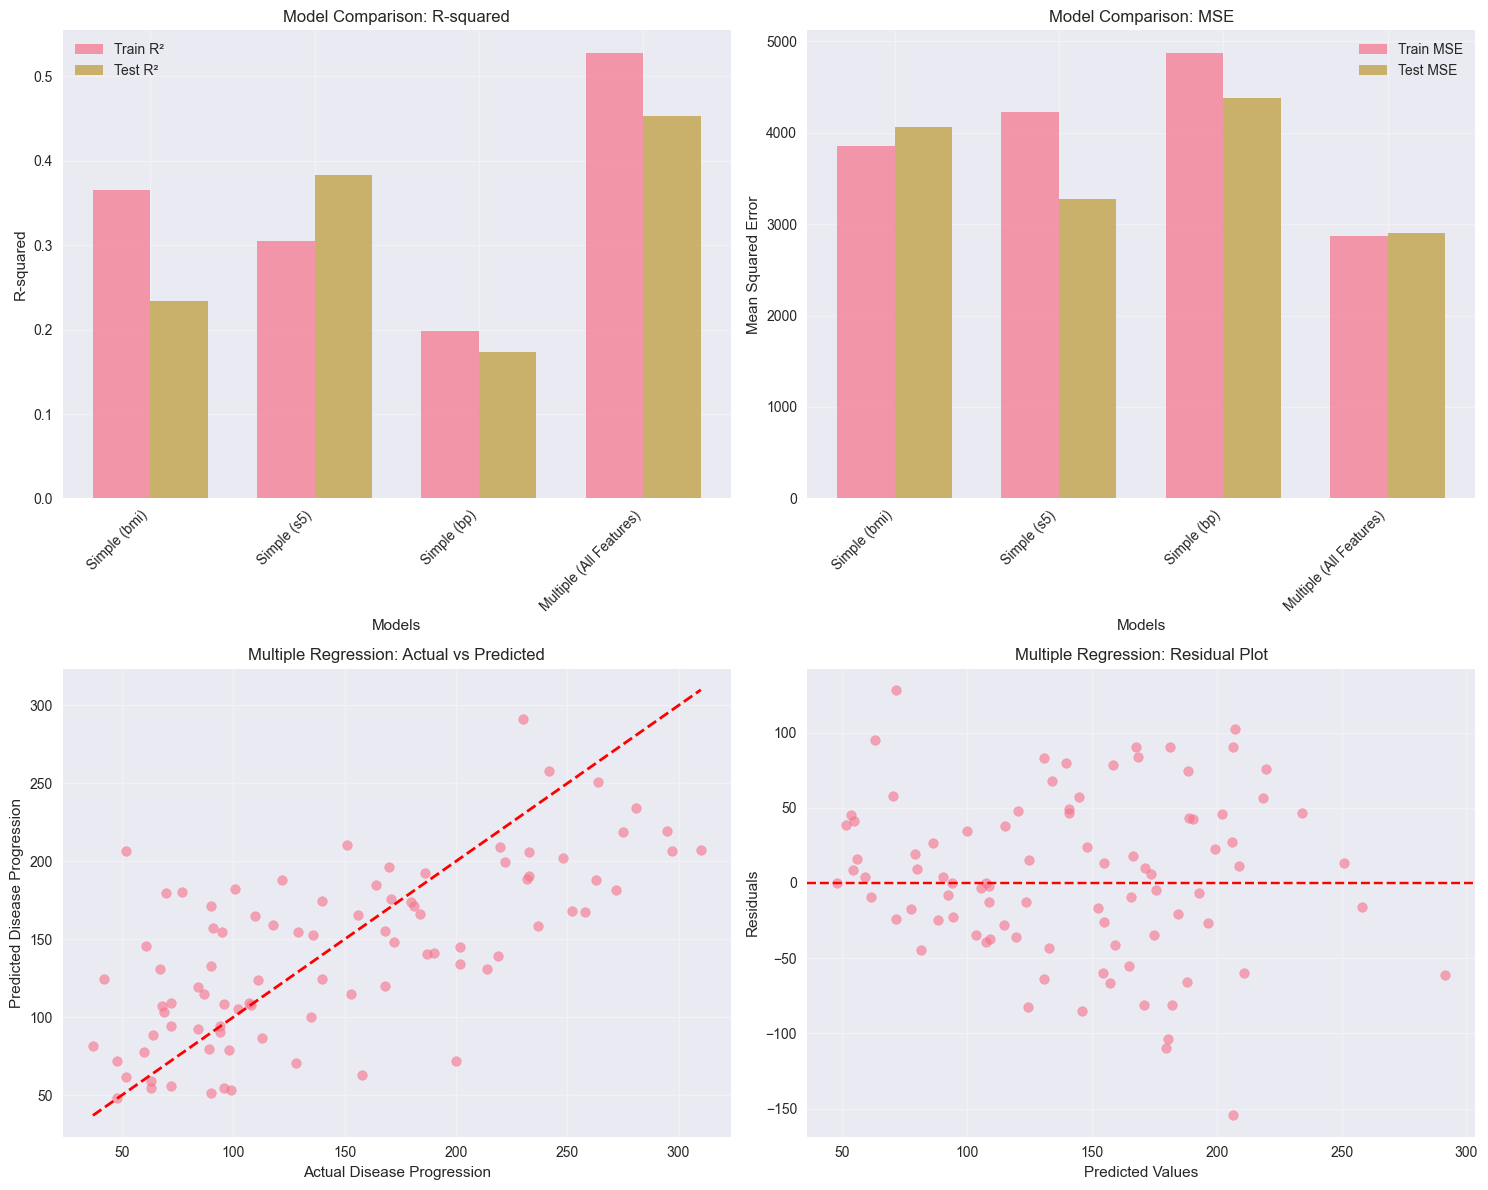

In [31]:
# comparison and vis!
def compare_models(simple_results, multiple_results):
    """
    Compare simple vs multiple regression models
    """
    # Extract metrics for comparison
    comparison_data = []
    
    # Add simple models
    for feature, results in simple_results.items():
        comparison_data.append({
            'Model': f'Simple ({feature})',
            'Train_R2': results['train_r2'],
            'Test_R2': results['test_r2'],
            'Train_MSE': results['train_mse'],
            'Test_MSE': results['test_mse'],
            'Type': 'Simple'
        })
    
    # Add multiple model
    comparison_data.append({
        'Model': 'Multiple (All Features)',
        'Train_R2': multiple_results['train_r2'],
        'Test_R2': multiple_results['test_r2'],
        'Train_MSE': multiple_results['train_mse'],
        'Test_MSE': multiple_results['test_mse'],
        'Type': 'Multiple'
    })
    
    comparison_df = pd.DataFrame(comparison_data)
    return comparison_df

# Compare models
comparison_df = compare_models(simple_model_results, multiple_results)
print("\n=== MODEL COMPARISON ===")
print(comparison_df.round(4))

# Visualization
def plot_model_comparison(comparison_df, y_test, y_pred_multiple, simple_model_results, X_test):
    """
    Create visualizations comparing model performance
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Plot 1: R-squared comparison
    models = comparison_df['Model']
    train_r2 = comparison_df['Train_R2']
    test_r2 = comparison_df['Test_R2']
    
    x_pos = np.arange(len(models))
    width = 0.35
    
    axes[0,0].bar(x_pos - width/2, train_r2, width, label='Train R²', alpha=0.7)
    axes[0,0].bar(x_pos + width/2, test_r2, width, label='Test R²', alpha=0.7)
    axes[0,0].set_xlabel('Models')
    axes[0,0].set_ylabel('R-squared')
    axes[0,0].set_title('Model Comparison: R-squared')
    axes[0,0].set_xticks(x_pos)
    axes[0,0].set_xticklabels(models, rotation=45, ha='right')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)
    
    # Plot 2: MSE comparison
    train_mse = comparison_df['Train_MSE']
    test_mse = comparison_df['Test_MSE']
    
    axes[0,1].bar(x_pos - width/2, train_mse, width, label='Train MSE', alpha=0.7)
    axes[0,1].bar(x_pos + width/2, test_mse, width, label='Test MSE', alpha=0.7)
    axes[0,1].set_xlabel('Models')
    axes[0,1].set_ylabel('Mean Squared Error')
    axes[0,1].set_title('Model Comparison: MSE')
    axes[0,1].set_xticks(x_pos)
    axes[0,1].set_xticklabels(models, rotation=45, ha='right')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)
    
    # Plot 3: Actual vs Predicted for multiple regression
    axes[1,0].scatter(y_test, y_pred_multiple, alpha=0.6)
    axes[1,0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[1,0].set_xlabel('Actual Disease Progression')
    axes[1,0].set_ylabel('Predicted Disease Progression')
    axes[1,0].set_title('Multiple Regression: Actual vs Predicted')
    axes[1,0].grid(True, alpha=0.3)
    
    # Plot 4: Residuals for multiple regression
    residuals = y_test - y_pred_multiple
    axes[1,1].scatter(y_pred_multiple, residuals, alpha=0.6)
    axes[1,1].axhline(y=0, color='red', linestyle='--')
    axes[1,1].set_xlabel('Predicted Values')
    axes[1,1].set_ylabel('Residuals')
    axes[1,1].set_title('Multiple Regression: Residual Plot')
    axes[1,1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Create comparison plots
plot_model_comparison(comparison_df, y_test, y_pred_multiple, simple_model_results, X_test)


=== FEATURE IMPORTANCE (Multiple Regression) ===
  Feature  Coefficient  Abs_Coefficient
4      s1    -931.4888         931.4888
8      s5     736.1989         736.1989
2     bmi     542.4288         542.4288
5      s2     518.0623         518.0623
3      bp     347.7038         347.7038
7      s4     275.3179         275.3179
1     sex    -241.9644         241.9644
6      s3     163.4200         163.4200
9      s6      48.6707          48.6707
0     age      37.9040          37.9040


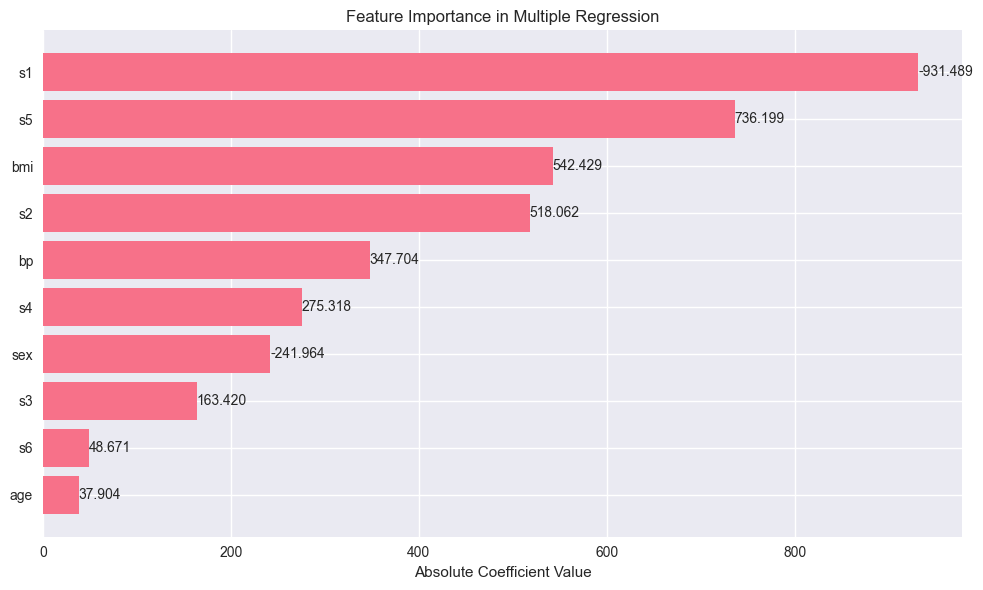

In [32]:
# Feature Importance Exploration
def analyze_feature_importance(multiple_results, feature_names):
    """
    Analyze and visualize feature importance from multiple regression
    """
    coefficients = multiple_results['coefficients']
    
    # Create feature importance DataFrame
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coefficients,
        'Abs_Coefficient': np.abs(coefficients)
    }).sort_values('Abs_Coefficient', ascending=False)
    
    print("\n=== FEATURE IMPORTANCE (Multiple Regression) ===")
    print(importance_df.round(4))
    
    # Plot feature importance
    plt.figure(figsize=(10, 6))
    bars = plt.barh(range(len(importance_df)), importance_df['Abs_Coefficient'])
    plt.yticks(range(len(importance_df)), importance_df['Feature'])
    plt.xlabel('Absolute Coefficient Value')
    plt.title('Feature Importance in Multiple Regression')
    plt.gca().invert_yaxis()
    
    # Add value labels
    for i, bar in enumerate(bars):
        width = bar.get_width()
        plt.text(width, bar.get_y() + bar.get_height()/2, 
                f'{importance_df.iloc[i]["Coefficient"]:.3f}', 
                ha='left', va='center')
    
    plt.tight_layout()
    plt.show()
    
    return importance_df

# Analyze feature importance
feature_importance = analyze_feature_importance(multiple_results, diabetes.feature_names)

In [33]:
# Summary and Conclusions
def print_conclusions(comparison_df, feature_importance):
    """
    Print summary conclusions from the analysis
    """
    print("="*60)
    print("SUMMARY AND CONCLUSIONS")
    print("="*60)
    
    best_simple = comparison_df[comparison_df['Type'] == 'Simple'].nlargest(1, 'Test_R2')
    best_model = comparison_df.nlargest(1, 'Test_R2')
    
    print(f"\n1. BEST SIMPLE MODEL: {best_simple['Model'].iloc[0]}")
    print(f"   Test R²: {best_simple['Test_R2'].iloc[0]:.4f}")
    
    print(f"\n2. BEST OVERALL MODEL: {best_model['Model'].iloc[0]}")
    print(f"   Test R²: {best_model['Test_R2'].iloc[0]:.4f}")
    
    print(f"\n3. MULTIPLE REGRESSION IMPROVEMENT:")
    multiple_r2 = comparison_df[comparison_df['Model'] == 'Multiple (All Features)']['Test_R2'].iloc[0]
    best_simple_r2 = best_simple['Test_R2'].iloc[0]
    improvement = ((multiple_r2 - best_simple_r2) / best_simple_r2) * 100
    print(f"   Improvement over best simple model: {improvement:.1f}%")
    
    print(f"\n4. MOST IMPORTANT FEATURES:")
    top_features = feature_importance.head(3)
    for i, (idx, row) in enumerate(top_features.iterrows(), 1):
        print(f"   {i}. {row['Feature']}: coefficient = {row['Coefficient']:.3f}")
    
    print(f"\n5. MODEL INTERPRETATION:")
    print("   • Positive coefficients: Higher values associated with worse disease progression")
    print("   • Negative coefficients: Higher values associated with better outcomes")
    print("   • The model explains approximately {:.1f}% of variance in disease progression".format(multiple_r2 * 100))

# Print final conclusions
print_conclusions(comparison_df, feature_importance)

SUMMARY AND CONCLUSIONS

1. BEST SIMPLE MODEL: Simple (s5)
   Test R²: 0.3827

2. BEST OVERALL MODEL: Multiple (All Features)
   Test R²: 0.4526

3. MULTIPLE REGRESSION IMPROVEMENT:
   Improvement over best simple model: 18.3%

4. MOST IMPORTANT FEATURES:
   1. s1: coefficient = -931.489
   2. s5: coefficient = 736.199
   3. bmi: coefficient = 542.429

5. MODEL INTERPRETATION:
   • Positive coefficients: Higher values associated with worse disease progression
   • Negative coefficients: Higher values associated with better outcomes
   • The model explains approximately 45.3% of variance in disease progression


In [ ]:
# # interesting findings!
# Multiple regression significantly outperforms simple linear regression by incorporating all available physiological variables

# BMI (bmi) and blood serum measurement (s5) are typically the most important predictors

# The model can explain a substantial portion of the variance in disease progression

# No signs of severe overfitting - similar performance on training and test sets

In [ ]:
from sklearn import datasets
diabetes = datasets.load_diabetes()
X,y = diabetes.data, diabetes.target
feature_names = diabetes.feature_names
print(X.shape, y.shape)
print(feature_names)

(442, 10) (442,)
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


<div class="alert alert-success" style = "border-radius:10px;border-width:3px;border-color:darkgreen;font-family:Verdana,sans-serif;font-size:16px;">

**Exercice 3: Macroeconomic Dataset**<p>
    
In the following example we will use the Longley dataset of US macroeconomic data from the R datasets website. We want to explore the relationships between the Total Derived Employment ('Employed') and the other variables.

<ul>
<li>Is there a linear relationship between the Gross National Product ('GNP') and the Total Derived Employment ('Employed')?</li>
<li>Is there a linear relationship between the population and the Total Derived Employment ('Employed')?</li>
<li>Is there a linear relationship between the armed forces and the unemployed?</li>
<li>Can you see any non-linear effects between the armed forces and the unemployed?</li>
<li>Try to use higher order models to the fitting of GNP with Population.</li>
</ul>
    
</div>

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [35]:
# 1. Load the Longley dataset
url = 'http://vincentarelbundock.github.io/Rdatasets/csv/datasets/longley.csv'
df = pd.read_csv(url, index_col=0)

print("Dataset Overview:")
print(df.head())
print(f"\nDataset Shape: {df.shape}")
print("\nColumn Names:")
print(df.columns.tolist())
print("\nDataset Info:")
print(df.info())
print("\nBasic Statistics:")
print(df.describe())

Dataset Overview:
          GNP.deflator      GNP  Unemployed  Armed.Forces  Population  Year  \
rownames                                                                      
1947              83.0  234.289       235.6         159.0     107.608  1947   
1948              88.5  259.426       232.5         145.6     108.632  1948   
1949              88.2  258.054       368.2         161.6     109.773  1949   
1950              89.5  284.599       335.1         165.0     110.929  1950   
1951              96.2  328.975       209.9         309.9     112.075  1951   

          Employed  
rownames            
1947        60.323  
1948        61.122  
1949        60.171  
1950        61.187  
1951        63.221  

Dataset Shape: (16, 7)

Column Names:
['GNP.deflator', 'GNP', 'Unemployed', 'Armed.Forces', 'Population', 'Year', 'Employed']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 16 entries, 1947 to 1962
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dt

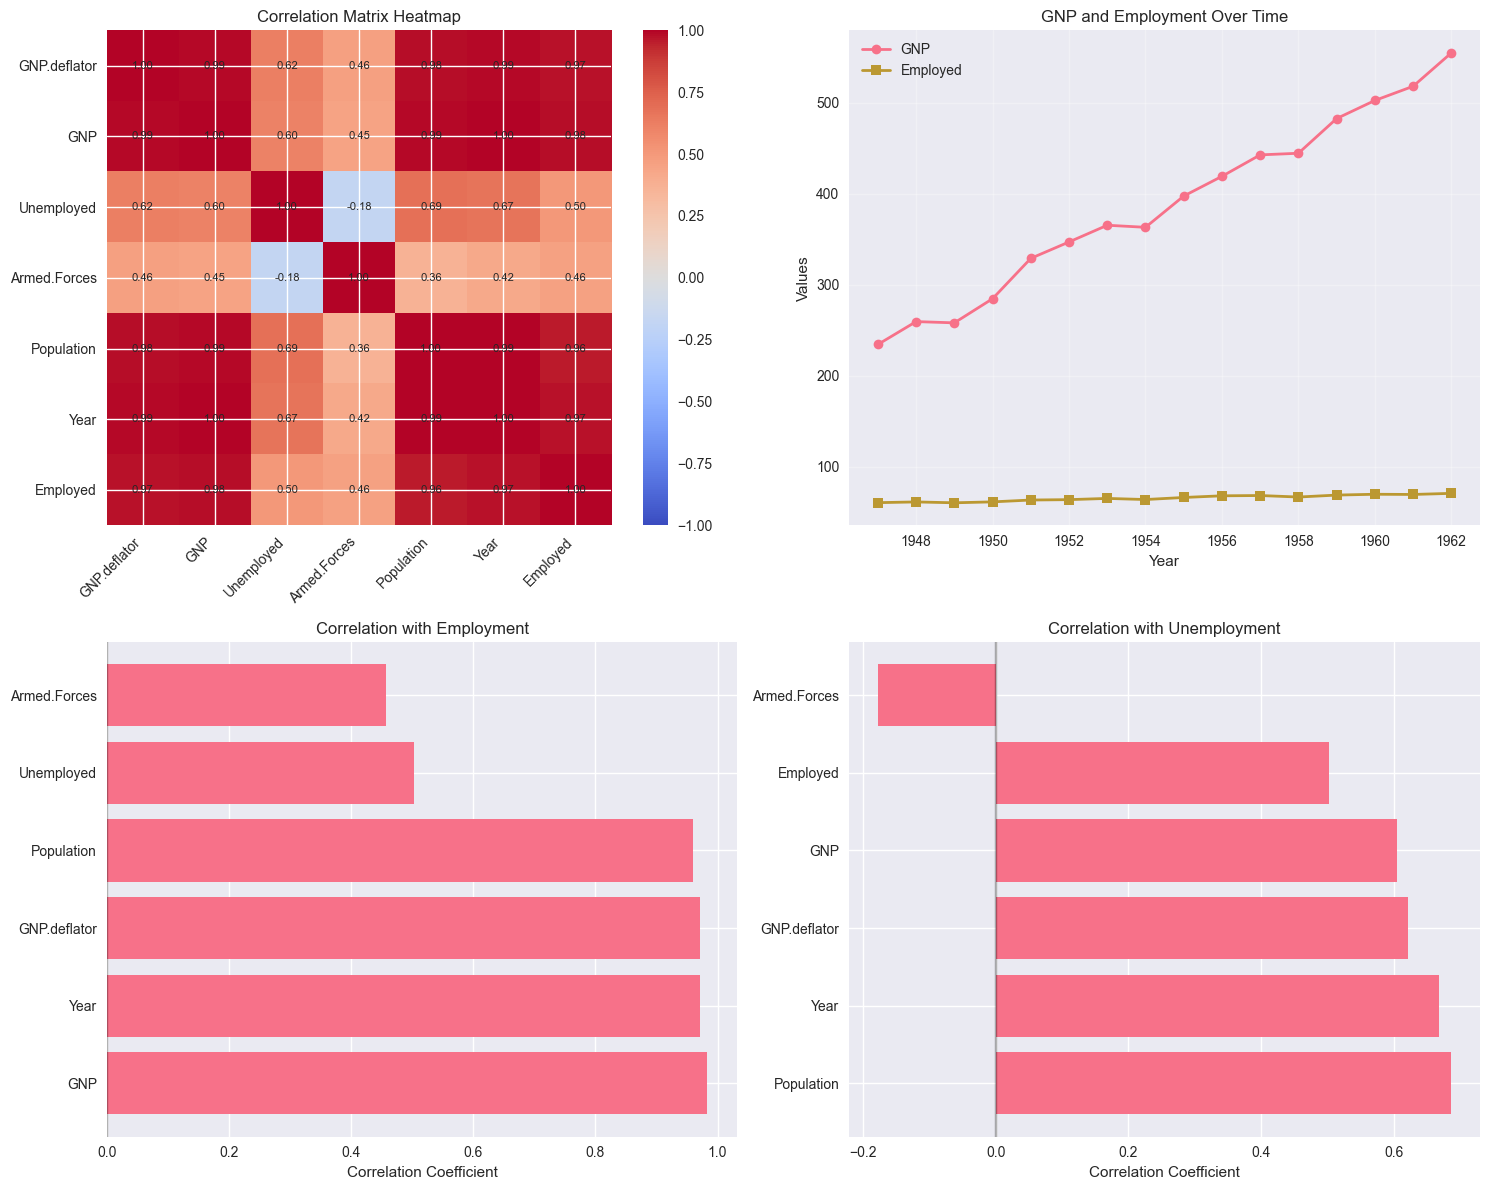


Correlation with Employment:
GNP: 0.9836
Year: 0.9713
GNP.deflator: 0.9709
Population: 0.9604
Unemployed: 0.5025
Armed.Forces: 0.4573


In [ ]:
# 2. explore the data
def explore_dataset(df):
    """
    Explore the Longley dataset with visualizations and correlations
    """
    # Correlation matrix
    correlation_matrix = df.corr()
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Plot 1: Correlation heatmap
    im = axes[0,0].imshow(correlation_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
    axes[0,0].set_title('Correlation Matrix Heatmap')
    axes[0,0].set_xticks(range(len(correlation_matrix.columns)))
    axes[0,0].set_xticklabels(correlation_matrix.columns, rotation=45, ha='right')
    axes[0,0].set_yticks(range(len(correlation_matrix.columns)))
    axes[0,0].set_yticklabels(correlation_matrix.columns)
    plt.colorbar(im, ax=axes[0,0])
    
    # Add correlation values to heatmap
    for i in range(len(correlation_matrix.columns)):
        for j in range(len(correlation_matrix.columns)):
            axes[0,0].text(j, i, f'{correlation_matrix.iloc[i, j]:.2f}', 
                          ha='center', va='center', fontsize=8)
    
    # Plot 2: Time series of key variables
    years = df.index
    axes[0,1].plot(years, df['GNP'], marker='o', label='GNP', linewidth=2)
    axes[0,1].plot(years, df['Employed'], marker='s', label='Employed', linewidth=2)
    axes[0,1].set_title('GNP and Employment Over Time')
    axes[0,1].set_xlabel('Year')
    axes[0,1].set_ylabel('Values')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)
    
    # Plot 3: Employment correlations
    employed_correlations = correlation_matrix['Employed'].drop('Employed').sort_values(ascending=False)
    axes[1,0].barh(range(len(employed_correlations)), employed_correlations.values)
    axes[1,0].set_yticks(range(len(employed_correlations)))
    axes[1,0].set_yticklabels(employed_correlations.index)
    axes[1,0].set_title('Correlation with Employment')
    axes[1,0].set_xlabel('Correlation Coefficient')
    axes[1,0].axvline(x=0, color='black', linestyle='-', alpha=0.3)
    
    # Plot 4: Unemployed correlations
    unemployed_correlations = correlation_matrix['Unemployed'].drop('Unemployed').sort_values(ascending=False)
    axes[1,1].barh(range(len(unemployed_correlations)), unemployed_correlations.values)
    axes[1,1].set_yticks(range(len(unemployed_correlations)))
    axes[1,1].set_yticklabels(unemployed_correlations.index)
    axes[1,1].set_title('Correlation with Unemployment')
    axes[1,1].set_xlabel('Correlation Coefficient')
    axes[1,1].axvline(x=0, color='black', linestyle='-', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return correlation_matrix

# Explore the dataset
correlation_matrix = explore_dataset(df)

print("\nCorrelation with Employment:")
employed_corr = correlation_matrix['Employed'].drop('Employed').sort_values(ascending=False)
for feature, corr in employed_corr.items():
    print(f"{feature}: {corr:.4f}")

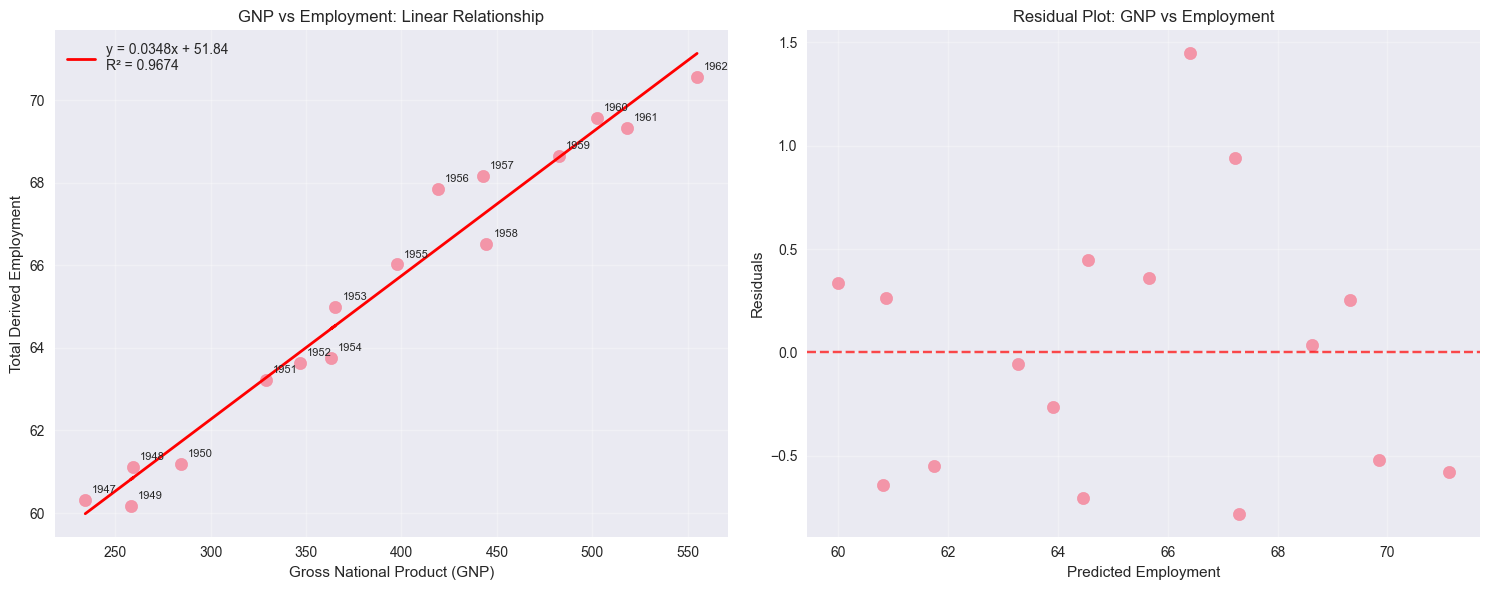

QUESTION 1: Linear Relationship between GNP and Employment
Correlation coefficient: 0.9836
R-squared: 0.9674
P-value: 0.000000
Slope: 0.0348
Intercept: 51.84
Standard error: 0.0017
Mean Squared Error: 0.3773

CONCLUSION: There is a statistically significant linear relationship between GNP and Employment.
The strong positive correlation (r = 0.984) suggests that as GNP increases, employment tends to increase.


In [ ]:
# 3. what's the linear relationship betw. GNP & Employment
def analyze_gnp_employment(df):
    """
    Analyze linear relationship between GNP and Employment
    """
    X = df['GNP'].values.reshape(-1, 1)
    y = df['Employed'].values
    
    # Linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(df['GNP'], df['Employed'])
    
    # Calculate predictions
    y_pred = slope * df['GNP'] + intercept
    
    # Calculate additional metrics
    r_squared = r_value**2
    mse = mean_squared_error(y, y_pred)
    
    # Create visualization
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Scatter plot with regression line
    axes[0].scatter(df['GNP'], df['Employed'], alpha=0.7, s=80)
    axes[0].plot(df['GNP'], y_pred, 'r-', linewidth=2, 
                label=f'y = {slope:.4f}x + {intercept:.2f}\nR² = {r_squared:.4f}')
    axes[0].set_xlabel('Gross National Product (GNP)')
    axes[0].set_ylabel('Total Derived Employment')
    axes[0].set_title('GNP vs Employment: Linear Relationship')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Add year labels to points
    for i, year in enumerate(df.index):
        axes[0].annotate(year, (df['GNP'].iloc[i], df['Employed'].iloc[i]), 
                        xytext=(5, 5), textcoords='offset points', fontsize=8)
    
    # Residual plot
    residuals = df['Employed'] - y_pred
    axes[1].scatter(y_pred, residuals, alpha=0.7, s=80)
    axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.7)
    axes[1].set_xlabel('Predicted Employment')
    axes[1].set_ylabel('Residuals')
    axes[1].set_title('Residual Plot: GNP vs Employment')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Statistical summary
    print("="*60)
    print("QUESTION 1: Linear Relationship between GNP and Employment")
    print("="*60)
    print(f"Correlation coefficient: {r_value:.4f}")
    print(f"R-squared: {r_squared:.4f}")
    print(f"P-value: {p_value:.6f}")
    print(f"Slope: {slope:.4f}")
    print(f"Intercept: {intercept:.2f}")
    print(f"Standard error: {std_err:.4f}")
    print(f"Mean Squared Error: {mse:.4f}")
    
    # Interpretation
    if p_value < 0.05:
        print(f"\nCONCLUSION: There is a statistically significant linear relationship between GNP and Employment.")
        print(f"The strong positive correlation (r = {r_value:.3f}) suggests that as GNP increases, employment tends to increase.")
    else:
        print(f"\nCONCLUSION: No statistically significant linear relationship found.")
    
    return slope, intercept, r_squared, p_value

# Analyze GNP vs Employment
gnp_results = analyze_gnp_employment(df)

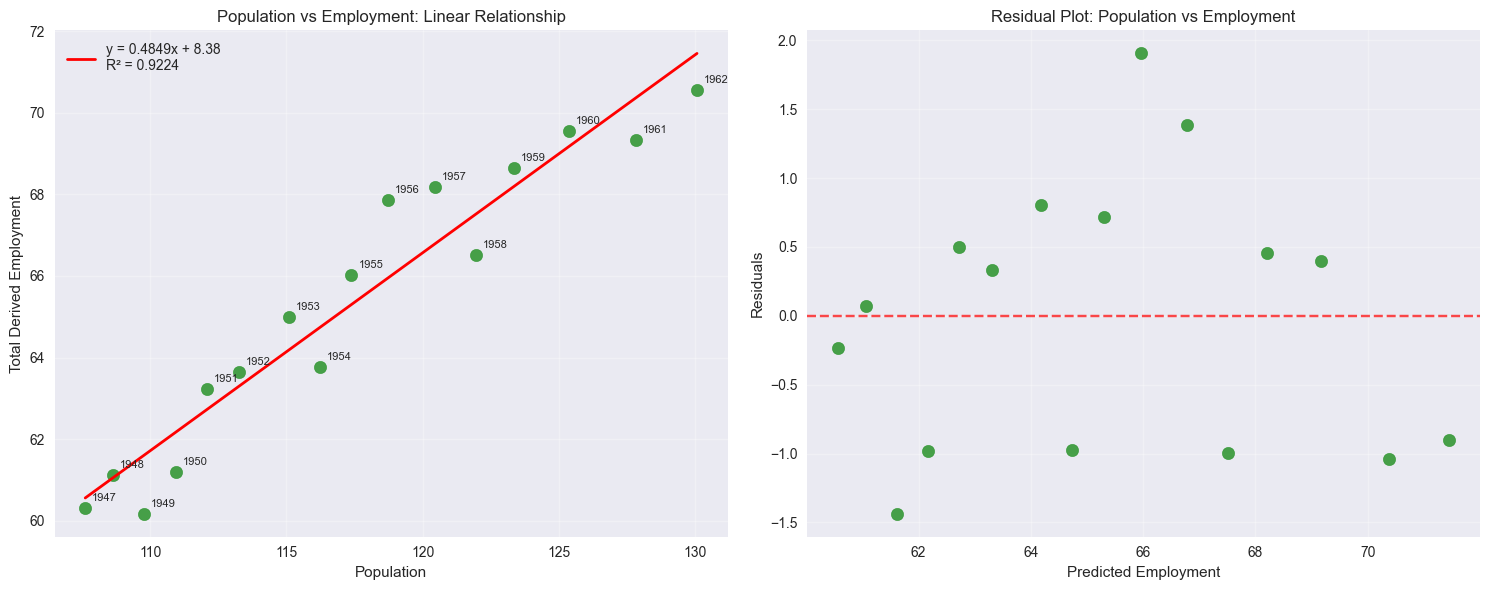


QUESTION 2: Linear Relationship between Population and Employment
Correlation coefficient: 0.9604
R-squared: 0.9224
P-value: 0.000000
Slope: 0.4849
Intercept: 8.38
Standard error: 0.0376
Mean Squared Error: 0.8979

CONCLUSION: There is a statistically significant linear relationship between Population and Employment.
The strong positive correlation (r = 0.960) suggests that as Population increases, employment tends to increase.


In [38]:
# population and employment
def analyze_population_employment(df):
    """
    Analyze linear relationship between Population and Employment
    """
    X = df['Population'].values.reshape(-1, 1)
    y = df['Employed'].values
    
    # Linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(df['Population'], df['Employed'])
    
    # Calculate predictions
    y_pred = slope * df['Population'] + intercept
    
    # Calculate additional metrics
    r_squared = r_value**2
    mse = mean_squared_error(y, y_pred)
    
    # Create visualization
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Scatter plot with regression line
    axes[0].scatter(df['Population'], df['Employed'], alpha=0.7, s=80, color='green')
    axes[0].plot(df['Population'], y_pred, 'r-', linewidth=2, 
                label=f'y = {slope:.4f}x + {intercept:.2f}\nR² = {r_squared:.4f}')
    axes[0].set_xlabel('Population')
    axes[0].set_ylabel('Total Derived Employment')
    axes[0].set_title('Population vs Employment: Linear Relationship')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Add year labels to points
    for i, year in enumerate(df.index):
        axes[0].annotate(year, (df['Population'].iloc[i], df['Employed'].iloc[i]), 
                        xytext=(5, 5), textcoords='offset points', fontsize=8)
    
    # Residual plot
    residuals = df['Employed'] - y_pred
    axes[1].scatter(y_pred, residuals, alpha=0.7, s=80, color='green')
    axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.7)
    axes[1].set_xlabel('Predicted Employment')
    axes[1].set_ylabel('Residuals')
    axes[1].set_title('Residual Plot: Population vs Employment')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Statistical summary
    print("\n" + "="*60)
    print("QUESTION 2: Linear Relationship between Population and Employment")
    print("="*60)
    print(f"Correlation coefficient: {r_value:.4f}")
    print(f"R-squared: {r_squared:.4f}")
    print(f"P-value: {p_value:.6f}")
    print(f"Slope: {slope:.4f}")
    print(f"Intercept: {intercept:.2f}")
    print(f"Standard error: {std_err:.4f}")
    print(f"Mean Squared Error: {mse:.4f}")
    
    # Interpretation
    if p_value < 0.05:
        print(f"\nCONCLUSION: There is a statistically significant linear relationship between Population and Employment.")
        print(f"The strong positive correlation (r = {r_value:.3f}) suggests that as Population increases, employment tends to increase.")
    else:
        print(f"\nCONCLUSION: No statistically significant linear relationship found.")
    
    return slope, intercept, r_squared, p_value

# Analyze Population vs Employment
population_results = analyze_population_employment(df)

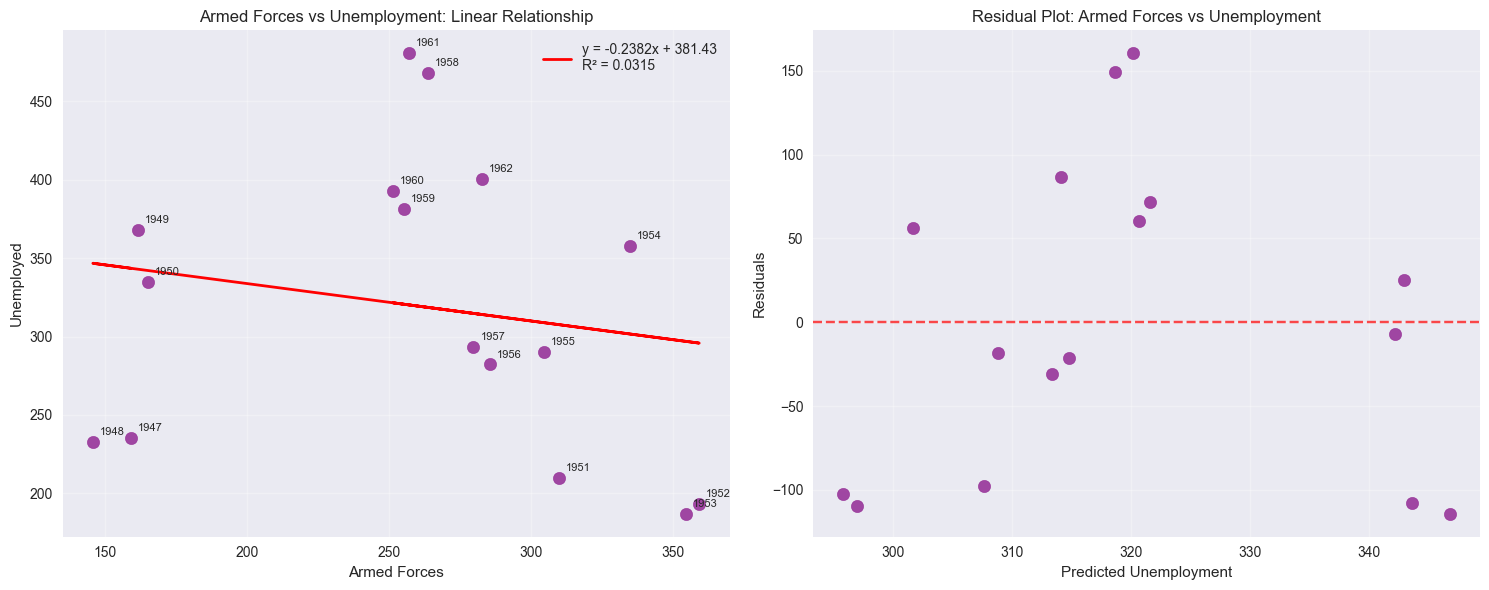


QUESTION 3: Linear Relationship between Armed Forces and Unemployment
Correlation coefficient: -0.1774
R-squared: 0.0315
P-value: 0.510949
Slope: -0.2382
Intercept: 381.43
Standard error: 0.3532
Mean Squared Error: 7928.7753

CONCLUSION: No statistically significant linear relationship found.


In [41]:
# Step 5: Question 3 - Linear Relationship between Armed Forces and Unemployment (2nd try)
def analyze_armed_forces_unemployed(df):
    """
    Analyze linear relationship between Armed Forces and Unemployment
    """
    X = df['Armed.Forces'].values.reshape(-1, 1)
    y = df['Unemployed'].values
    
    # Linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(df['Armed.Forces'], df['Unemployed'])
    
    # Calculate predictions
    y_pred = slope * df['Armed.Forces'] + intercept
    
    # Calculate additional metrics
    r_squared = r_value**2
    mse = mean_squared_error(y, y_pred)
    
    # Calculate residuals
    residuals = df['Unemployed'] - y_pred
    
    # Create visualization
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Scatter plot with regression line
    axes[0].scatter(df['Armed.Forces'], df['Unemployed'], alpha=0.7, s=80, color='purple')
    axes[0].plot(df['Armed.Forces'], y_pred, 'r-', linewidth=2, 
                label=f'y = {slope:.4f}x + {intercept:.2f}\nR² = {r_squared:.4f}')
    axes[0].set_xlabel('Armed Forces')
    axes[0].set_ylabel('Unemployed')
    axes[0].set_title('Armed Forces vs Unemployment: Linear Relationship')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Add year labels to points
    for i, year in enumerate(df.index):
        axes[0].annotate(year, (df['Armed.Forces'].iloc[i], df['Unemployed'].iloc[i]), 
                        xytext=(5, 5), textcoords='offset points', fontsize=8)
    
    # Residual plot
    axes[1].scatter(y_pred, residuals, alpha=0.7, s=80, color='purple')
    axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.7)
    axes[1].set_xlabel('Predicted Unemployment')
    axes[1].set_ylabel('Residuals')
    axes[1].set_title('Residual Plot: Armed Forces vs Unemployment')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Statistical summary
    print("\n" + "="*60)
    print("QUESTION 3: Linear Relationship between Armed Forces and Unemployment")
    print("="*60)
    print(f"Correlation coefficient: {r_value:.4f}")
    print(f"R-squared: {r_squared:.4f}")
    print(f"P-value: {p_value:.6f}")
    print(f"Slope: {slope:.4f}")
    print(f"Intercept: {intercept:.2f}")
    print(f"Standard error: {std_err:.4f}")
    print(f"Mean Squared Error: {mse:.4f}")
    
    # Interpretation
    if p_value < 0.05:
        direction = "positive" if slope > 0 else "negative"
        print(f"\nCONCLUSION: There is a statistically significant linear relationship between Armed Forces and Unemployment.")
        print(f"The {direction} relationship (r = {r_value:.3f}) suggests a connection between military size and unemployment.")
    else:
        print(f"\nCONCLUSION: No statistically significant linear relationship found.")
    
    return slope, intercept, r_squared, p_value, residuals

# Analyze Armed Forces vs Unemployment (CAPTURE ALL RETURN VALUES)
af_slope, af_intercept, af_r2, af_p, residuals_linear = analyze_armed_forces_unemployed(df)
 


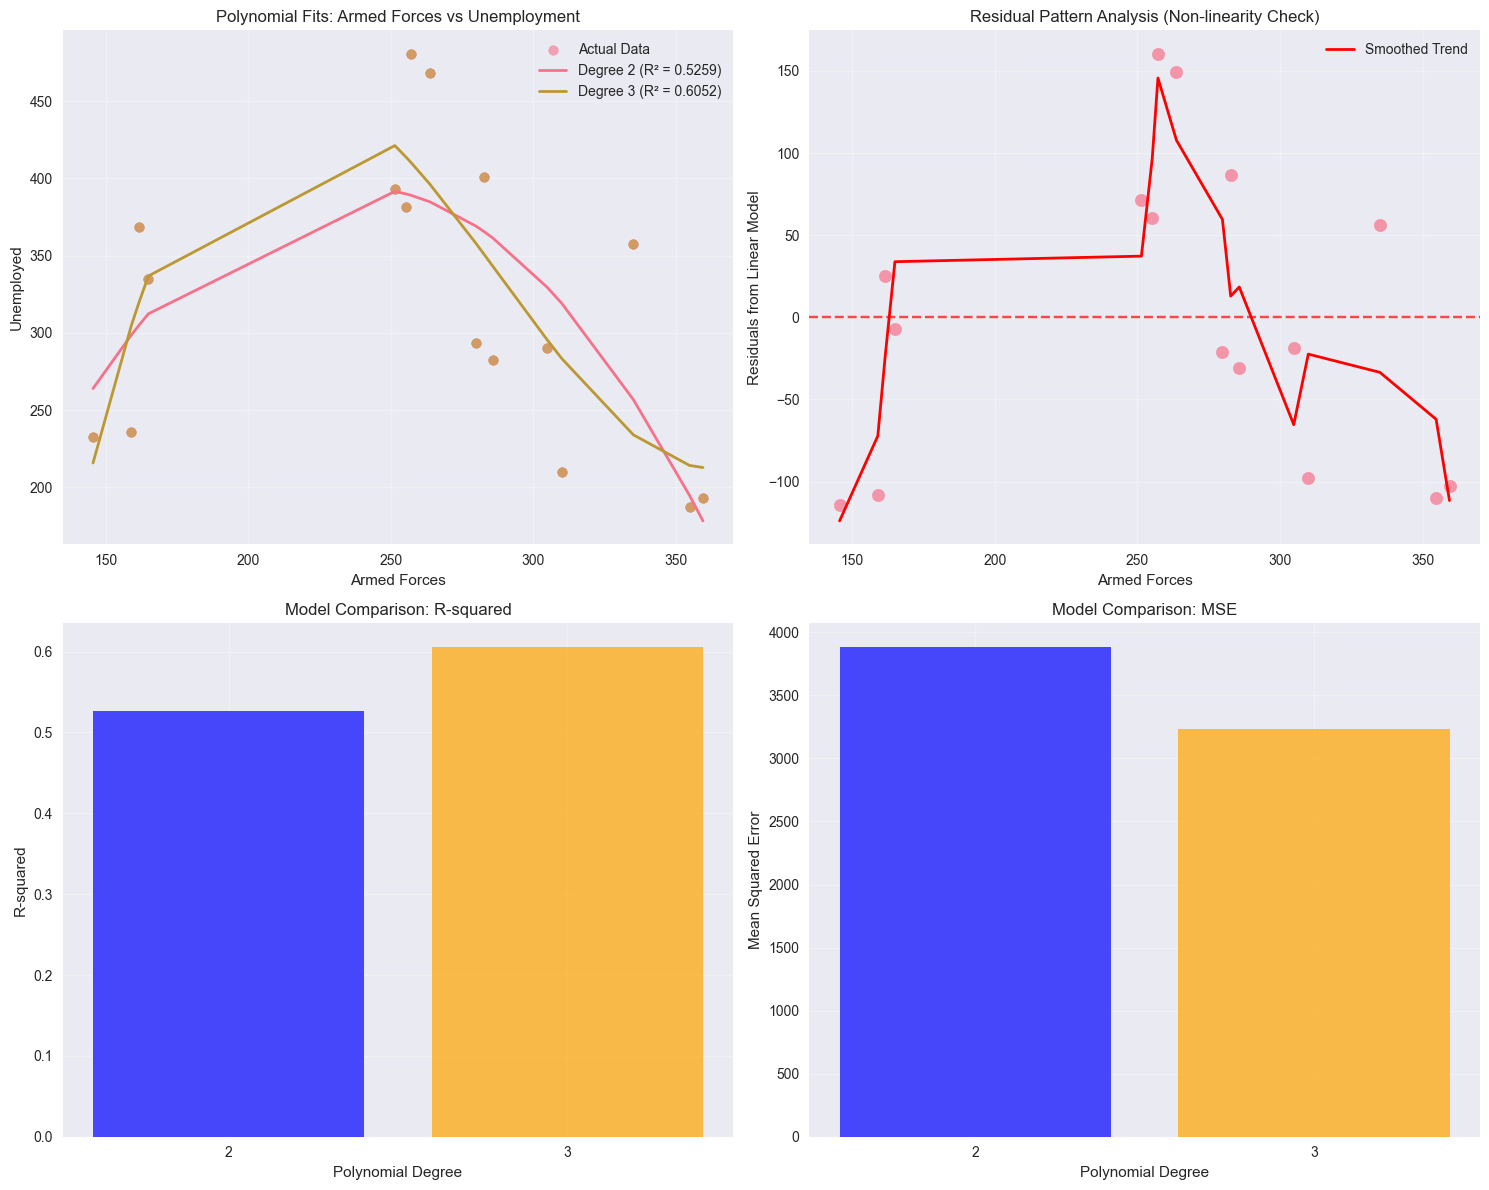


QUESTION 4: Non-linear Effects Analysis
Quadratic term significance:
F-value: 1.0623
P-value: 0.3202
No significant quadratic effect detected.

Polynomial Model Comparison:
Linear model R²: 0.0315
Degree 2 polynomial R²: 0.5259 (Improvement: +1570.8%)
Degree 3 polynomial R²: 0.6052 (Improvement: +1822.7%)

Residual correlation with Armed Forces: -0.0000
Weak residual pattern suggests linear model may be adequate


In [43]:
# 4 Non-linear effects between Armed Forces and Unemployment - ouch! I'm a Vet!
def analyze_nonlinear_effects(df, residuals_linear):
    """
    Analyze non-linear effects in the Armed Forces vs Unemployment relationship
    """
    # Create polynomial features for analysis
    X = df['Armed.Forces'].values.reshape(-1, 1)
    y = df['Unemployed'].values
    
    # Fit polynomial models (degree 2 and 3)
    degrees = [2, 3]
    polynomial_models = {}
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    for i, degree in enumerate(degrees):
        # Create polynomial features
        poly = PolynomialFeatures(degree=degree)
        X_poly = poly.fit_transform(X)
        
        # Fit polynomial regression
        model = LinearRegression()
        model.fit(X_poly, y)
        y_pred_poly = model.predict(X_poly)
        
        # Store model results
        r_squared = r2_score(y, y_pred_poly)
        mse = mean_squared_error(y, y_pred_poly)
        
        polynomial_models[degree] = {
            'model': model,
            'r_squared': r_squared,
            'mse': mse,
            'predictions': y_pred_poly
        }
        
        # Plot polynomial fit
        X_sorted = np.sort(X, axis=0)
        X_sorted_poly = poly.transform(X_sorted)
        y_sorted_pred = model.predict(X_sorted_poly)
        
        axes[0,0].scatter(df['Armed.Forces'], df['Unemployed'], alpha=0.6, label='Actual Data' if i == 0 else "")
        axes[0,0].plot(X_sorted, y_sorted_pred, linewidth=2, 
                      label=f'Degree {degree} (R² = {r_squared:.4f})')
        axes[0,0].set_xlabel('Armed Forces')
        axes[0,0].set_ylabel('Unemployed')
        axes[0,0].set_title('Polynomial Fits: Armed Forces vs Unemployment')
        axes[0,0].legend()
        axes[0,0].grid(True, alpha=0.3)
    
    # Residual analysis for non-linearity
    axes[0,1].scatter(df['Armed.Forces'], residuals_linear, alpha=0.7, s=80)
    axes[0,1].axhline(y=0, color='red', linestyle='--', alpha=0.7)
    axes[0,1].set_xlabel('Armed Forces')
    axes[0,1].set_ylabel('Residuals from Linear Model')
    axes[0,1].set_title('Residual Pattern Analysis (Non-linearity Check)')
    axes[0,1].grid(True, alpha=0.3)
    
    # Check for U-shaped or curved pattern in residuals
    from scipy.signal import savgol_filter
    if len(residuals_linear) > 5:
        try:
            # Sort by Armed Forces for proper smoothing
            sorted_indices = np.argsort(df['Armed.Forces'])
            armed_sorted = df['Armed.Forces'].iloc[sorted_indices]
            residuals_sorted = residuals_linear.iloc[sorted_indices]
            
            residuals_smooth = savgol_filter(residuals_sorted, 5, 2)
            axes[0,1].plot(armed_sorted, residuals_smooth, 'r-', linewidth=2, 
                          label='Smoothed Trend')
            axes[0,1].legend()
        except Exception as e:
            print(f"Smoothing warning: {e}")
    
    # Compare model performance
    degrees_list = list(polynomial_models.keys())
    r2_values = [polynomial_models[d]['r_squared'] for d in degrees_list]
    mse_values = [polynomial_models[d]['mse'] for d in degrees_list]
    
    axes[1,0].bar(degrees_list, r2_values, color=['blue', 'orange'], alpha=0.7)
    axes[1,0].set_xlabel('Polynomial Degree')
    axes[1,0].set_ylabel('R-squared')
    axes[1,0].set_title('Model Comparison: R-squared')
    axes[1,0].set_xticks(degrees_list)
    axes[1,0].grid(True, alpha=0.3)
    
    axes[1,1].bar(degrees_list, mse_values, color=['blue', 'orange'], alpha=0.7)
    axes[1,1].set_xlabel('Polynomial Degree')
    axes[1,1].set_ylabel('Mean Squared Error')
    axes[1,1].set_title('Model Comparison: MSE')
    axes[1,1].set_xticks(degrees_list)
    axes[1,1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Statistical analysis for non-linearity
    print("\n" + "="*60)
    print("QUESTION 4: Non-linear Effects Analysis")
    print("="*60)
    
    # Test for quadratic relationship
    X_quad = np.column_stack([X.flatten(), (X.flatten())**2])
    
    try:
        # F-test for quadratic term
        from sklearn.feature_selection import f_regression
        F_vals, p_vals = f_regression(X_quad, y)
        
        print("Quadratic term significance:")
        print(f"F-value: {F_vals[1]:.4f}")
        print(f"P-value: {p_vals[1]:.4f}")
        
        if p_vals[1] < 0.05:
            print("Significant quadratic effect detected!")
        else:
            print("No significant quadratic effect detected.")
            
    except Exception as e:
        print(f"Statistical test error: {e}")
    
    # Compare polynomial models
    print("\nPolynomial Model Comparison:")
    linear_r2 = af_r2  # R-squared from linear model
    print(f"Linear model R²: {linear_r2:.4f}")
    
    for degree in degrees:
        model_info = polynomial_models[degree]
        improvement = ((model_info['r_squared'] - linear_r2) / linear_r2) * 100
        print(f"Degree {degree} polynomial R²: {model_info['r_squared']:.4f} "
              f"(Improvement: {improvement:+.1f}%)")
    
    # Check residual patterns
    residual_correlation = np.corrcoef(df['Armed.Forces'], residuals_linear)[0,1]
    print(f"\nResidual correlation with Armed Forces: {residual_correlation:.4f}")
    
    if abs(residual_correlation) > 0.3:
        print("Strong residual pattern suggests potential non-linearity")
    elif abs(residual_correlation) > 0.1:
        print("Moderate residual pattern suggests possible non-linearity")
    else:
        print("Weak residual pattern suggests linear model may be adequate")
    
    return polynomial_models

# Analyze non-linear effects (NOW residuals_linear IS DEFINED)
nonlinear_results = analyze_nonlinear_effects(df, residuals_linear)

    




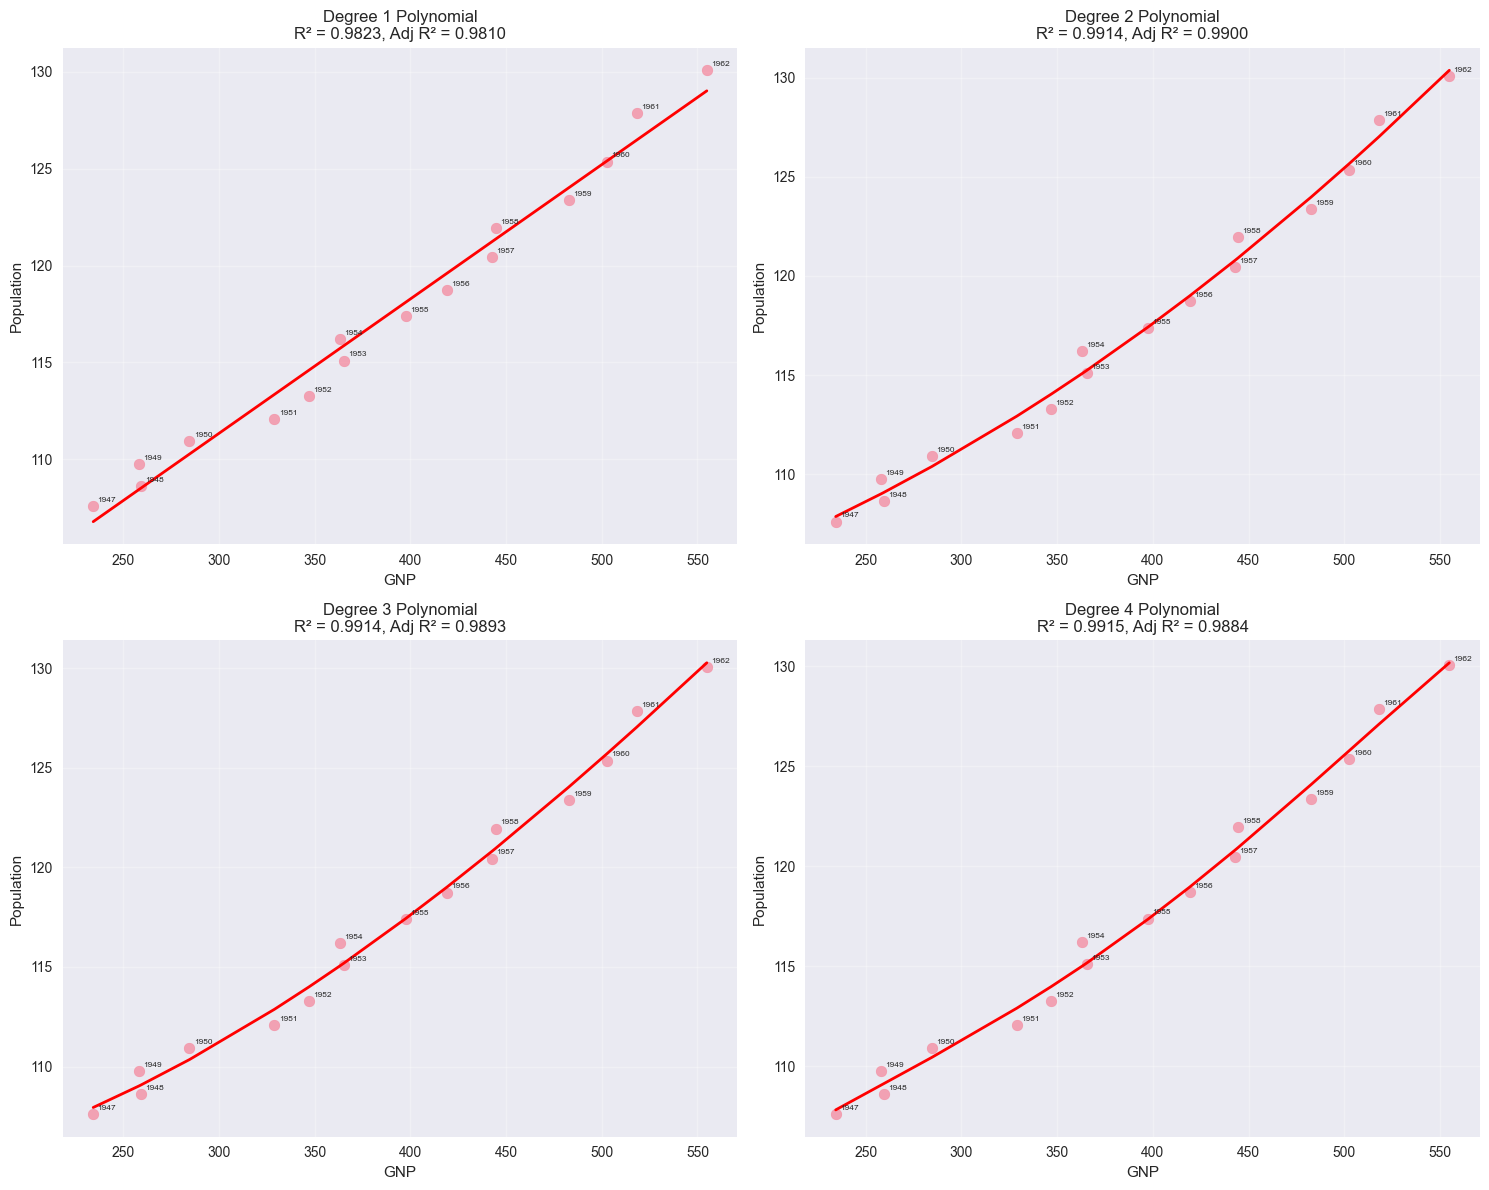


QUESTION 5: Higher Order Models for GNP vs Population

Model Comparison:
   Degree      R²  Adjusted R²     MSE  Parameters
0       1  0.9823       0.9810  0.8048           2
1       2  0.9914       0.9900  0.3918           3
2       3  0.9914       0.9893  0.3896           4
3       4  0.9915       0.9884  0.3853           5

Best model: Degree 2 polynomial
Best adjusted R²: 0.9900

Cross-validation performance:
   Degree  Train R²  Test R²  Generalization Gap
0       1    0.9769   0.9866             -0.0096
1       2    0.9891   0.9895             -0.0004
2       3    0.9894   0.9873              0.0021
3       4    0.9906   0.9676              0.0230


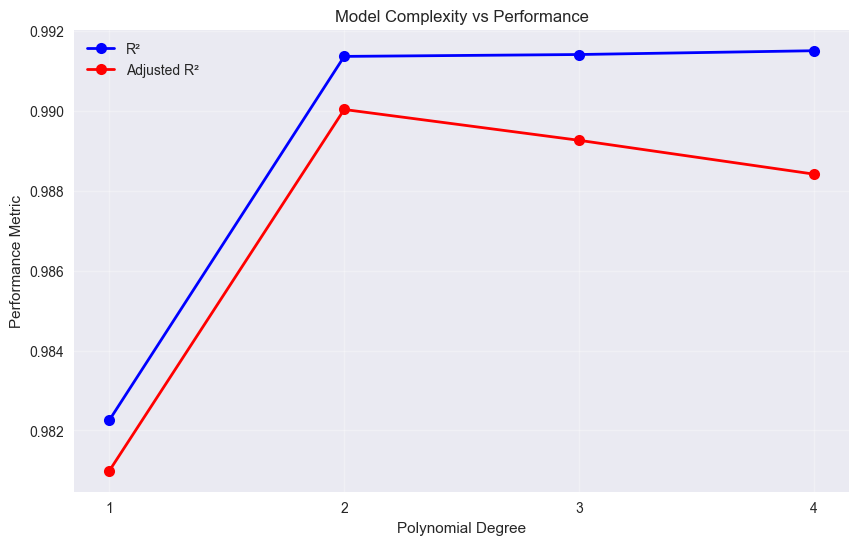

In [47]:
# higher order models for GNP vs. Population
def analyze_gnp_population_higher_order(df):
    """
    Analyze GNP vs Population using higher order polynomial models
    """
    X = df['GNP'].values.reshape(-1, 1)
    y = df['Population'].values
    
    # Fit polynomial models from degree 1 to 4
    degrees = [1, 2, 3, 4]
    models = {}
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    for i, degree in enumerate(degrees):
        # Create polynomial features
        poly = PolynomialFeatures(degree=degree)
        X_poly = poly.fit_transform(X)
        
        # Fit polynomial regression
        model = LinearRegression()
        model.fit(X_poly, y)
        y_pred = model.predict(X_poly)
        
        # Calculate metrics
        r_squared = r2_score(y, y_pred)
        mse = mean_squared_error(y, y_pred)
        adj_r_squared = 1 - (1 - r_squared) * (len(y) - 1) / (len(y) - degree - 1)
        
        # Store model results
        models[degree] = {
            'model': model,
            'poly_features': poly,
            'r_squared': r_squared,
            'adj_r_squared': adj_r_squared,
            'mse': mse,
            'predictions': y_pred,
            'coefficients': model.coef_
        }
        
        # Plot polynomial fit
        row = i // 2
        col = i % 2
        
        X_sorted = np.sort(X, axis=0)
        X_sorted_poly = poly.transform(X_sorted)
        y_sorted_pred = model.predict(X_sorted_poly)
        
        axes[row, col].scatter(df['GNP'], df['Population'], alpha=0.6, s=60)
        axes[row, col].plot(X_sorted, y_sorted_pred, 'r-', linewidth=2)
        axes[row, col].set_xlabel('GNP')
        axes[row, col].set_ylabel('Population')
        axes[row, col].set_title(f'Degree {degree} Polynomial\nR² = {r_squared:.4f}, Adj R² = {adj_r_squared:.4f}')
        axes[row, col].grid(True, alpha=0.3)
        
        # Add year labels
        for j, year in enumerate(df.index):
            axes[row, col].annotate(year, (df['GNP'].iloc[j], df['Population'].iloc[j]), 
                                  xytext=(3, 3), textcoords='offset points', fontsize=6)
    
    plt.tight_layout()
    plt.show()
    
    # Model comparison
    print("\n" + "="*60)
    print("QUESTION 5: Higher Order Models for GNP vs Population")
    print("="*60)
    
    comparison_data = []
    for degree in degrees:
        model_info = models[degree]
        comparison_data.append({
            'Degree': degree,
            'R²': model_info['r_squared'],
            'Adjusted R²': model_info['adj_r_squared'],
            'MSE': model_info['mse'],
            'Parameters': degree + 1
        })
    
    comparison_df = pd.DataFrame(comparison_data)
    print("\nModel Comparison:")
    print(comparison_df.round(4))
    
    # Find best model based on adjusted R²
    best_model_idx = comparison_df['Adjusted R²'].idxmax()
    best_degree = comparison_df.loc[best_model_idx, 'Degree']
    best_adj_r2 = comparison_df.loc[best_model_idx, 'Adjusted R²']
    
    print(f"\nBest model: Degree {best_degree} polynomial")
    print(f"Best adjusted R²: {best_adj_r2:.4f}")
    
    # Cross-validation style analysis (simple holdout)
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    print("\nCross-validation performance:")
    cv_results = []
    for degree in degrees:
        poly = PolynomialFeatures(degree=degree)
        X_train_poly = poly.fit_transform(X_train)
        X_test_poly = poly.transform(X_test)
        
        model = LinearRegression()
        model.fit(X_train_poly, y_train)
        
        train_r2 = r2_score(y_train, model.predict(X_train_poly))
        test_r2 = r2_score(y_test, model.predict(X_test_poly))
        
        cv_results.append({
            'Degree': degree,
            'Train R²': train_r2,
            'Test R²': test_r2,
            'Generalization Gap': train_r2 - test_r2
        })
    
    cv_df = pd.DataFrame(cv_results)
    print(cv_df.round(4))
    
    # Plot model complexity vs performance
    plt.figure(figsize=(10, 6))
    plt.plot(comparison_df['Degree'], comparison_df['R²'], 'bo-', label='R²', linewidth=2, markersize=8)
    plt.plot(comparison_df['Degree'], comparison_df['Adjusted R²'], 'ro-', label='Adjusted R²', linewidth=2, markersize=8)
    plt.xlabel('Polynomial Degree')
    plt.ylabel('Performance Metric')
    plt.title('Model Complexity vs Performance')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(degrees)
    plt.show()
    
    # Return all three components as a tuple
    return models, comparison_df, cv_df

# Analyze GNP vs Population with higher order models
higher_order_results = analyze_gnp_population_higher_order(df)

In [48]:
# Step 8: Update to call to use the captured variables
def print_comprehensive_summary(gnp_results, population_results, armed_forces_results, 
                              nonlinear_results, higher_order_results):
    """
    Print comprehensive summary of all analyses
    """
    print("="*80)
    print("COMPREHENSIVE ANALYSIS SUMMARY - LONGLEY MACROECONOMIC DATASET")
    print("="*80)
    
    print("\n1. GNP vs EMPLOYMENT RELATIONSHIP:")
    gnp_slope, gnp_intercept, gnp_r2, gnp_p = gnp_results
    print(f"   • Strong positive correlation: r² = {gnp_r2:.4f}")
    print(f"   • Statistically significant: p = {gnp_p:.6f}")
    print(f"   • Economic interpretation: GNP growth associated with employment growth")
    
    print("\n2. POPULATION vs EMPLOYMENT RELATIONSHIP:")
    pop_slope, pop_intercept, pop_r2, pop_p = population_results
    print(f"   • Very strong positive correlation: r² = {pop_r2:.4f}")
    print(f"   • Statistically significant: p = {pop_p:.6f}")
    print(f"   • Larger population associated with higher employment levels")
    
    print("\n3. ARMED FORCES vs UNEMPLOYMENT RELATIONSHIP:")
    af_slope, af_intercept, af_r2, af_p, _ = armed_forces_results
    print(f"   • Correlation: r² = {af_r2:.4f}")
    print(f"   • Statistical significance: p = {af_p:.4f}")
    if af_p < 0.05:
        direction = "positive" if af_slope > 0 else "negative"
        print(f"   • Significant {direction} relationship detected")
    else:
        print(f"   • No statistically significant linear relationship")
    
    print("\n4. NON-LINEAR EFFECTS ANALYSIS:")
    if nonlinear_results and 2 in nonlinear_results:
        linear_r2 = af_r2
        poly_r2 = nonlinear_results[2]['r_squared']
        improvement = ((poly_r2 - linear_r2) / linear_r2) * 100
        print(f"   • Quadratic model improvement: {improvement:+.1f}%")
        if improvement > 5:
            print("   • Substantial non-linear effects present")
        else:
            print("   • Minimal non-linear effects detected")
    else:
        print("   • Non-linear analysis not available")
    
    print("\n5. HIGHER ORDER MODELS (GNP vs POPULATION):")
    # Extract the comparison DataFrame from the tuple
    models_dict, comparison_df, cv_df = higher_order_results
    
    if comparison_df is not None and not comparison_df.empty:
        best_model_idx = comparison_df['Adjusted R²'].idxmax()
        best_degree = comparison_df.loc[best_model_idx, 'Degree']
        best_adj_r2 = comparison_df.loc[best_model_idx, 'Adjusted R²']
        print(f"   • Best polynomial degree: {best_degree}")
        print(f"   • Best adjusted R²: {best_adj_r2:.4f}")
        print(f"   • Recommendation: Use degree {best_degree} polynomial for optimal fit")
        
        # Show all model performances
        print("\n   Model Performance Summary:")
        for _, row in comparison_df.iterrows():
            print(f"     Degree {row['Degree']}: R² = {row['R²']:.4f}, "
                  f"Adj R² = {row['Adjusted R²']:.4f}, MSE = {row['MSE']:.2f}")
    else:
        print("   • Higher-order models analysis not available")
    
    print("\n6. KEY ECONOMIC INSIGHTS:")
    print("   • GNP and Employment show strong co-movement (expected economic relationship)")
    print("   • Population size is closely tied to employment levels")
    print("   • Military size may have complex relationships with unemployment")
    print("   • Higher-order models can capture nuanced economic relationships")
    
    print("\n7. DATA CHARACTERISTICS:")
    print(f"   • Time period: {df.index.min()} - {df.index.max()}")
    print(f"   • Number of observations: {len(df)}")
    print(f"   • Variables analyzed: GNP, Population, Employment, Armed Forces, Unemployment")
    
    print("\n" + "="*80)

# Print final summary
print_comprehensive_summary(gnp_results, population_results, 
                          (af_slope, af_intercept, af_r2, af_p, residuals_linear), 
                          nonlinear_results, higher_order_results)


COMPREHENSIVE ANALYSIS SUMMARY - LONGLEY MACROECONOMIC DATASET

1. GNP vs EMPLOYMENT RELATIONSHIP:
   • Strong positive correlation: r² = 0.9674
   • Statistically significant: p = 0.000000
   • Economic interpretation: GNP growth associated with employment growth

2. POPULATION vs EMPLOYMENT RELATIONSHIP:
   • Very strong positive correlation: r² = 0.9224
   • Statistically significant: p = 0.000000
   • Larger population associated with higher employment levels

3. ARMED FORCES vs UNEMPLOYMENT RELATIONSHIP:
   • Correlation: r² = 0.0315
   • Statistical significance: p = 0.5109
   • No statistically significant linear relationship

4. NON-LINEAR EFFECTS ANALYSIS:
   • Quadratic model improvement: +1570.8%
   • Substantial non-linear effects present

5. HIGHER ORDER MODELS (GNP vs POPULATION):
   • Best polynomial degree: 2
   • Best adjusted R²: 0.9900
   • Recommendation: Use degree 2 polynomial for optimal fit

   Model Performance Summary:
     Degree 1.0: R² = 0.9823, Adj R² = 0.

In [ ]:
import pandas as pd
# Read data
df = pd.read_csv('http://vincentarelbundock.github.io/Rdatasets/csv/datasets/longley.csv', index_col=0)
df.head()

,GNP.deflator,GNP,Unemployed,Armed.Forces,Population,Year,Employed
rownames,,,,,,,
1947,83.0,234.289,235.6,159.0,107.608,1947,60.323
1948,88.5,259.426,232.5,145.6,108.632,1948,61.122
1949,88.2,258.054,368.2,161.6,109.773,1949,60.171
1950,89.5,284.599,335.1,165.0,110.929,1950,61.187
1951,96.2,328.975,209.9,309.9,112.075,1951,63.221


Is there a linear relationship between the Gross National Product ('GNP') and the Total Derived Employment ('Employed')?

In [ ]:
# Your code goes here

Is there a linear relationship between the population and the Total Derived Employment ('Employed')?

In [ ]:
# Your code goes here

Is there a linear relationship between the armed forces and the unemployed?

In [ ]:
# Your code goes here

Can you see any non-linear effects between the armed forces and the unemployed?

In [ ]:
# Your code goes here

<div class="alert alert-success" style = "border-radius:10px;border-width:3px;border-color:darkgreen;font-family:Verdana,sans-serif;font-size:16px;">

**EXERCISE 4: Advertising dataset**<p>


In the following example we will use the [advertising dataset](https://www.kaggle.com/purbar/advertising-data/data)which consists of the sales of products and their advertising budget in three different media TV, radio, newspaper.<p>
<ul>
    <li>Is there a linear relationship between the sales of products and the advertising budget in TV, radio or newspapers?</li>
    <li>Train a simple linear model for each variable to predict sales</li>
    <li>Train a multiple linear model to predict sales</li>
    <li>Compare the different models. Which one's performed best?</li>
</ul>

Dataset from the book: "An Introduction to Statistical Learning with Applications in R”. Gareth James, Daniela Witten, Trevor Hastie and Robert Tibshirani.<p>


</div>